# Exploratory Data Analysis (EDA)

## Microfinance Loan Repayment Prediction

### 1. Introduction

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, quality, and relationships present in the microfinance loan repayment dataset.

The objective of this analysis is to identify important patterns in customer recharge, loan, repayment, and usage behaviour that may help predict whether a customer will repay a microcredit loan within the required period.

The cleaned dataset obtained after the data cleaning stage will be used for this analysis.

### Objectives of EDA

- Understand the structure and characteristics of the dataset.
- Analyze the distribution of the target variable.
- Identify class imbalance between defaulters and non-defaulters.
- Study the distributions of numerical features.
- Analyze relationships between features.
- Identify potential outliers and unusual patterns.
- Examine the relationship between customer behaviour and loan repayment.
- Identify potentially useful features for feature engineering and model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

# Dataset path
DATA_PATH = "../data/processed/microfinance_cleaned_base.csv"

# Visualization output directory
EDA_OUTPUT_PATH = Path("../visualizations/eda")
EDA_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Load cleaned dataset
df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("MICROFINANCE LOAN REPAYMENT — EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

MICROFINANCE LOAN REPAYMENT — EXPLORATORY DATA ANALYSIS

Dataset loaded successfully.
Shape: (209593, 34)
Rows: 209593
Columns: 34


## 2. Dataset Overview

The cleaned dataset contains customer-level information related to mobile recharge behaviour, loan usage, repayment behaviour, and the target variable indicating loan repayment status.

The dataset contains 209,593 records and 34 columns.

The target variable is `label`:

- `1` — Non-defaulter: the customer repaid the loan within the required period.
- `0` — Defaulter: the customer did not repay the loan within the required period.

This section examines the structure, data types, and basic characteristics of the dataset before performing detailed analysis.

In [2]:
print("First 5 records:")
display(df.head())

First 5 records:


,label,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,last_rech_amt_ma,cnt_ma_rech30,fr_ma_rech30,sumamnt_ma_rech30,medianamnt_ma_rech30,medianmarechprebal30,cnt_ma_rech90,fr_ma_rech90,sumamnt_ma_rech90,medianamnt_ma_rech90,medianmarechprebal90,cnt_da_rech30,fr_da_rech30,cnt_da_rech90,fr_da_rech90,cnt_loans30,amnt_loans30,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,payback30,payback90,pdate
0,0,272.0,3055.050000,3065.150000,220.13,260.13,2.0,0.0,1539,2,21.0,3078.0,1539.0,7.50,2,21,3078,1539.0,7.50,0.0,0.0,0,0.0,2,12,6.0,0.0,2.0,12,6,0.0,29.000000,29.000000,2016-07-20
1,1,712.0,12122.000000,12124.750000,3691.26,3691.26,20.0,0.0,5787,1,0.0,5787.0,5787.0,61.04,1,0,5787,5787.0,61.04,0.0,0.0,0,0.0,1,12,12.0,0.0,1.0,12,12,0.0,0.000000,0.000000,2016-08-10
2,1,535.0,1398.000000,1398.000000,900.13,900.13,3.0,0.0,1539,1,0.0,1539.0,1539.0,66.32,1,0,1539,1539.0,66.32,0.0,0.0,0,0.0,1,6,6.0,0.0,1.0,6,6,0.0,0.000000,0.000000,2016-08-19
3,1,241.0,21.228000,21.228000,159.42,159.42,41.0,0.0,947,0,0.0,0.0,0.0,0.00,1,0,947,947.0,2.50,0.0,0.0,0,0.0,2,12,6.0,0.0,2.0,12,6,0.0,0.000000,0.000000,2016-06-06
4,1,947.0,150.619333,150.619333,1098.90,1098.90,4.0,0.0,2309,7,2.0,20029.0,2309.0,29.00,8,2,23496,2888.0,35.00,0.0,0.0,0,0.0,7,42,6.0,0.0,7.0,42,6,0.0,2.333333,2.333333,2016-06-22


In [3]:
print("Last 5 records:")
display(df.tail())

Last 5 records:


,label,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,last_rech_amt_ma,cnt_ma_rech30,fr_ma_rech30,sumamnt_ma_rech30,medianamnt_ma_rech30,medianmarechprebal30,cnt_ma_rech90,fr_ma_rech90,sumamnt_ma_rech90,medianamnt_ma_rech90,medianmarechprebal90,cnt_da_rech30,fr_da_rech30,cnt_da_rech90,fr_da_rech90,cnt_loans30,amnt_loans30,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,payback30,payback90,pdate
209588,1,404.0,151.872333,151.872333,1089.19,1089.19,1.0,0.0,4048,3,2.0,10404.0,3178.0,91.81,3,2,10404,3178.0,91.81,0.0,0.0,0,0.0,2,12,6.0,0.0,2.0,12,6,0.0,1.0,1.000000,2016-06-17
209589,1,1075.0,36.936000,36.936000,1728.36,1728.36,4.0,0.0,773,4,1.0,3092.0,773.0,161.30,6,2,4038,773.0,111.80,0.0,0.0,0,0.0,3,18,6.0,0.0,3.0,18,6,0.0,1.0,1.000000,2016-06-12
209590,1,1013.0,11843.111667,11904.350000,5861.83,8893.20,3.0,0.0,1539,5,8.0,9334.0,1539.0,51.13,11,5,18592,1539.0,47.13,0.0,0.0,0,0.0,4,42,12.0,0.0,6.0,54,12,0.0,4.0,3.833333,2016-07-29
209591,1,1732.0,12488.228333,12574.370000,411.83,984.58,2.0,38.0,773,5,4.0,12154.0,773.0,164.00,6,4,17941,2410.5,100.00,0.0,0.0,1,0.0,2,18,12.0,0.0,3.0,24,12,0.0,0.0,10.500000,2016-07-25
209592,1,1581.0,4489.362000,4534.820000,483.92,631.20,13.0,0.0,7526,2,1.0,9065.0,4532.5,356.70,3,19,16591,7526.0,392.20,0.0,0.0,0,0.0,2,18,12.0,0.0,2.0,18,12,0.0,0.0,0.000000,2016-07-07


In [4]:
print("Dataset Information")
print("=" * 70)

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 209593 entries, 0 to 209592
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   label                 209593 non-null  int64  
 1   aon                   209593 non-null  float64
 2   daily_decr30          209593 non-null  float64
 3   daily_decr90          209593 non-null  float64
 4   rental30              209593 non-null  float64
 5   rental90              209593 non-null  float64
 6   last_rech_date_ma     209593 non-null  float64
 7   last_rech_date_da     209593 non-null  float64
 8   last_rech_amt_ma      209593 non-null  int64  
 9   cnt_ma_rech30         209593 non-null  int64  
 10  fr_ma_rech30          209593 non-null  float64
 11  sumamnt_ma_rech30     209593 non-null  float64
 12  medianamnt_ma_rech30  209593 non-null  float64
 13  medianmarechprebal30  209593 non-null  float64
 14  cnt_ma_rech90         209593 non-null  int6

In [5]:
print("Column Names")
print("=" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

Column Names
 1. label
 2. aon
 3. daily_decr30
 4. daily_decr90
 5. rental30
 6. rental90
 7. last_rech_date_ma
 8. last_rech_date_da
 9. last_rech_amt_ma
10. cnt_ma_rech30
11. fr_ma_rech30
12. sumamnt_ma_rech30
13. medianamnt_ma_rech30
14. medianmarechprebal30
15. cnt_ma_rech90
16. fr_ma_rech90
17. sumamnt_ma_rech90
18. medianamnt_ma_rech90
19. medianmarechprebal90
20. cnt_da_rech30
21. fr_da_rech30
22. cnt_da_rech90
23. fr_da_rech90
24. cnt_loans30
25. amnt_loans30
26. maxamnt_loans30
27. medianamnt_loans30
28. cnt_loans90
29. amnt_loans90
30. maxamnt_loans90
31. medianamnt_loans90
32. payback30
33. payback90
34. pdate


In [6]:
print("Dataset Shape:", df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (209593, 34)

Number of Rows: 209593
Number of Columns: 34


## 3. Data Quality Assessment

Before performing detailed exploratory analysis, the quality of the cleaned dataset is assessed.

The following checks are performed:

- Missing values
- Duplicate records
- Data types
- Unique values
- Constant columns
- Target variable validity

These checks help ensure that the dataset is suitable for further exploratory analysis and machine learning.

In [7]:
# Check missing values

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing_Count",
    ascending=False
)

display(missing_summary)

print("\nTotal missing cells:", df.isnull().sum().sum())

,Missing_Count,Missing_Percentage
label,0,0.0
aon,0,0.0
daily_decr30,0,0.0
daily_decr90,0,0.0
rental30,0,0.0
rental90,0,0.0
last_rech_date_ma,0,0.0
last_rech_date_da,0,0.0
last_rech_amt_ma,0,0.0
cnt_ma_rech30,0,0.0



Total missing cells: 0


In [8]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 31


In [9]:
# Check data types

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values
})

display(dtype_summary)

,Column,Data_Type
0,label,int64
1,aon,float64
2,daily_decr30,float64
3,daily_decr90,float64
4,rental30,float64
5,rental90,float64
6,last_rech_date_ma,float64
7,last_rech_date_da,float64
8,last_rech_amt_ma,int64
9,cnt_ma_rech30,int64


In [10]:
# Number of unique values in each column

unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique() for col in df.columns]
})

unique_summary = unique_summary.sort_values(
    by="Unique_Values",
    ascending=True
)

display(unique_summary)

,Column,Unique_Values
0,label,2
29,maxamnt_loans90,3
26,medianamnt_loans30,6
30,medianamnt_loans90,6
21,cnt_da_rech90,27
23,cnt_loans30,40
22,fr_da_rech90,46
24,amnt_loans30,48
28,amnt_loans90,69
8,last_rech_amt_ma,70


In [11]:
# Identify columns containing only one unique value

constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
[]


In [12]:
# Check target variable

print("Target variable: label")
print("\nUnique target values:")
print(sorted(df["label"].unique()))

print("\nTarget distribution:")
print(df["label"].value_counts())

print("\nTarget proportions:")
print(df["label"].value_counts(normalize=True))

Target variable: label

Unique target values:
[np.int64(0), np.int64(1)]

Target distribution:
label
1    183431
0     26162
Name: count, dtype: int64

Target proportions:
label
1    0.875177
0    0.124823
Name: proportion, dtype: float64


In [13]:
# Overall data quality summary

quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Cells",
        "Duplicate Rows",
        "Unique Customers",
        "Target Classes"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["msisdn"].nunique() if "msisdn" in df.columns else "N/A",
        df["label"].nunique()
    ]
})

display(quality_summary)

,Metric,Value
0,Total Rows,209593
1,Total Columns,34
2,Missing Cells,0
3,Duplicate Rows,31
4,Unique Customers,N/A
5,Target Classes,2


## 4. Target Variable Analysis

The target variable `label` represents the repayment outcome of the customer.

- `1` represents the majority repayment class.
- `0` represents the minority repayment class.

The distribution of the target variable is analyzed to identify class imbalance.

Understanding the target distribution is important because a highly imbalanced target can affect machine learning model performance and evaluation.

In [14]:
# Target variable distribution

target_counts = df["label"].value_counts().sort_index()

target_percentage = (
    df["label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentage.round(2)
})

display(target_summary)

,Count,Percentage
label,,
0,26162,12.48
1,183431,87.52


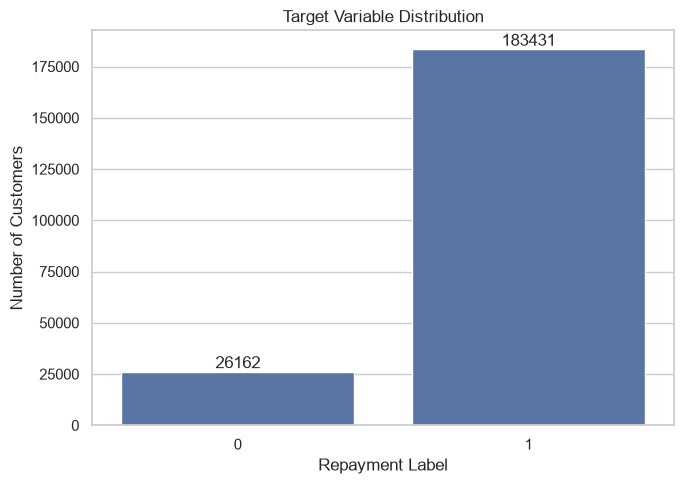

In [15]:
# Visualize target distribution

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="label"
)

plt.title("Target Variable Distribution")
plt.xlabel("Repayment Label")
plt.ylabel("Number of Customers")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

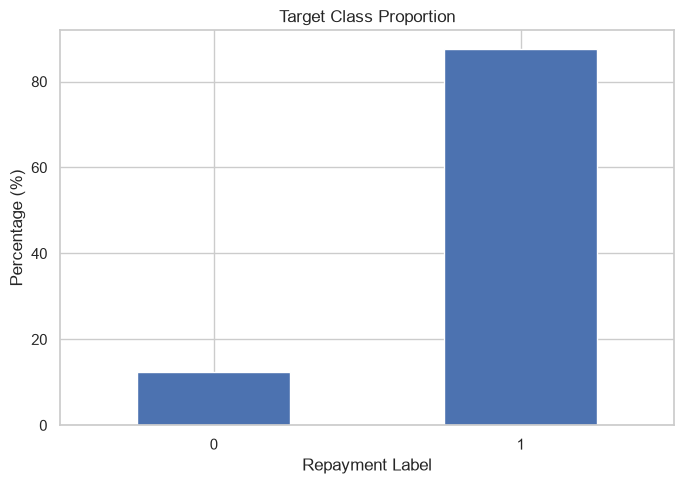

In [16]:
# Target class proportions

plt.figure(figsize=(7, 5))

target_percentage.plot(
    kind="bar"
)

plt.title("Target Class Proportion")
plt.xlabel("Repayment Label")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
# Print target analysis

majority_class = target_counts.idxmax()
minority_class = target_counts.idxmin()

majority_percentage = target_percentage[majority_class]
minority_percentage = target_percentage[minority_class]

print("Majority class:", majority_class)
print("Majority class percentage:", round(majority_percentage, 2), "%")

print("Minority class:", minority_class)
print("Minority class percentage:", round(minority_percentage, 2), "%")

print("\nClass imbalance ratio:")
print(
    round(
        target_counts[majority_class] / target_counts[minority_class],
        2
    )
)

Majority class: 1
Majority class percentage: 87.52 %
Minority class: 0
Minority class percentage: 12.48 %

Class imbalance ratio:
7.01


## 5. Numerical Feature Distribution Analysis

The dataset contains several numerical features describing customer activity, recharge behavior, loan activity, repayment behavior, and financial usage patterns.

Distribution analysis is performed to understand:

- Central tendency and spread
- Skewness
- Possible outliers
- Feature ranges
- Differences in feature distributions

Histograms and box plots are used to identify the underlying distribution of the numerical variables.

In [20]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Remove target variable
numerical_features = [
    col for col in numerical_columns
    if col != "label"
]

print("Number of numerical features:", len(numerical_features))
print("\nNumerical features:")
print(numerical_features)

Number of numerical features: 32

Numerical features:
['aon', 'daily_decr30', 'daily_decr90', 'rental30', 'rental90', 'last_rech_date_ma', 'last_rech_date_da', 'last_rech_amt_ma', 'cnt_ma_rech30', 'fr_ma_rech30', 'sumamnt_ma_rech30', 'medianamnt_ma_rech30', 'medianmarechprebal30', 'cnt_ma_rech90', 'fr_ma_rech90', 'sumamnt_ma_rech90', 'medianamnt_ma_rech90', 'medianmarechprebal90', 'cnt_da_rech30', 'fr_da_rech30', 'cnt_da_rech90', 'fr_da_rech90', 'cnt_loans30', 'amnt_loans30', 'maxamnt_loans30', 'medianamnt_loans30', 'cnt_loans90', 'amnt_loans90', 'maxamnt_loans90', 'medianamnt_loans90', 'payback30', 'payback90']


In [21]:
# Statistical summary of numerical features

numerical_summary = df[numerical_features].describe().T

numerical_summary["skewness"] = df[numerical_features].skew()

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max,skewness
aon,209593.0,6274.063189,63311.417753,-48.000000,246.000,525.000000,977.00,899968.078244,11.464163
daily_decr30,209593.0,5381.402289,9220.623400,-93.012667,42.440,1469.175667,7244.00,265926.000000,3.946230
daily_decr90,209593.0,6082.515068,10918.812767,-93.012667,42.692,1500.000000,7802.79,320630.000000,4.252565
rental30,209593.0,2692.581910,4308.586781,-23737.140000,280.420,1083.570000,3356.94,198926.110000,4.521929
rental90,209593.0,3483.406534,5770.461279,-24720.580000,300.260,1334.000000,4201.79,200148.110000,4.437681
last_rech_date_ma,209593.0,2768.518157,44432.201212,-29.000000,1.000,3.000000,7.00,899991.527898,16.429941
last_rech_date_da,209593.0,2778.791418,44359.346151,-29.000000,0.000,0.000000,0.00,899816.210847,16.315431
last_rech_amt_ma,209593.0,2064.452797,2370.786034,0.000000,770.000,1539.000000,2309.00,55000.000000,3.781149
cnt_ma_rech30,209593.0,3.978057,4.256090,0.000000,1.000,3.000000,5.00,203.000000,3.283842
fr_ma_rech30,209593.0,2862.583902,45294.601638,0.000000,0.000,2.000000,6.00,899853.109731,16.178396


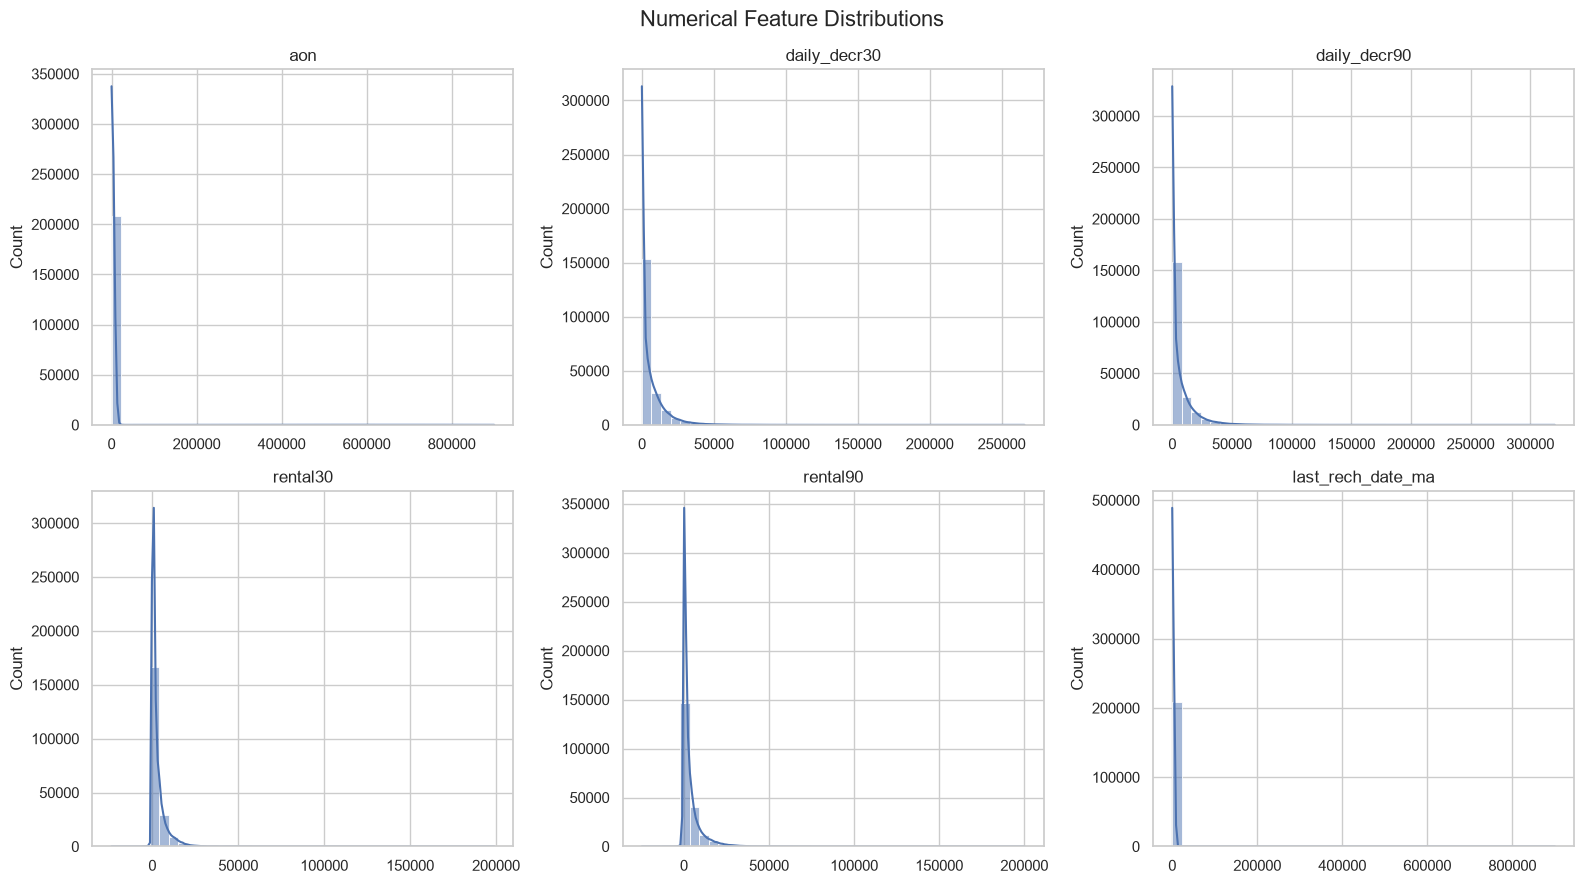

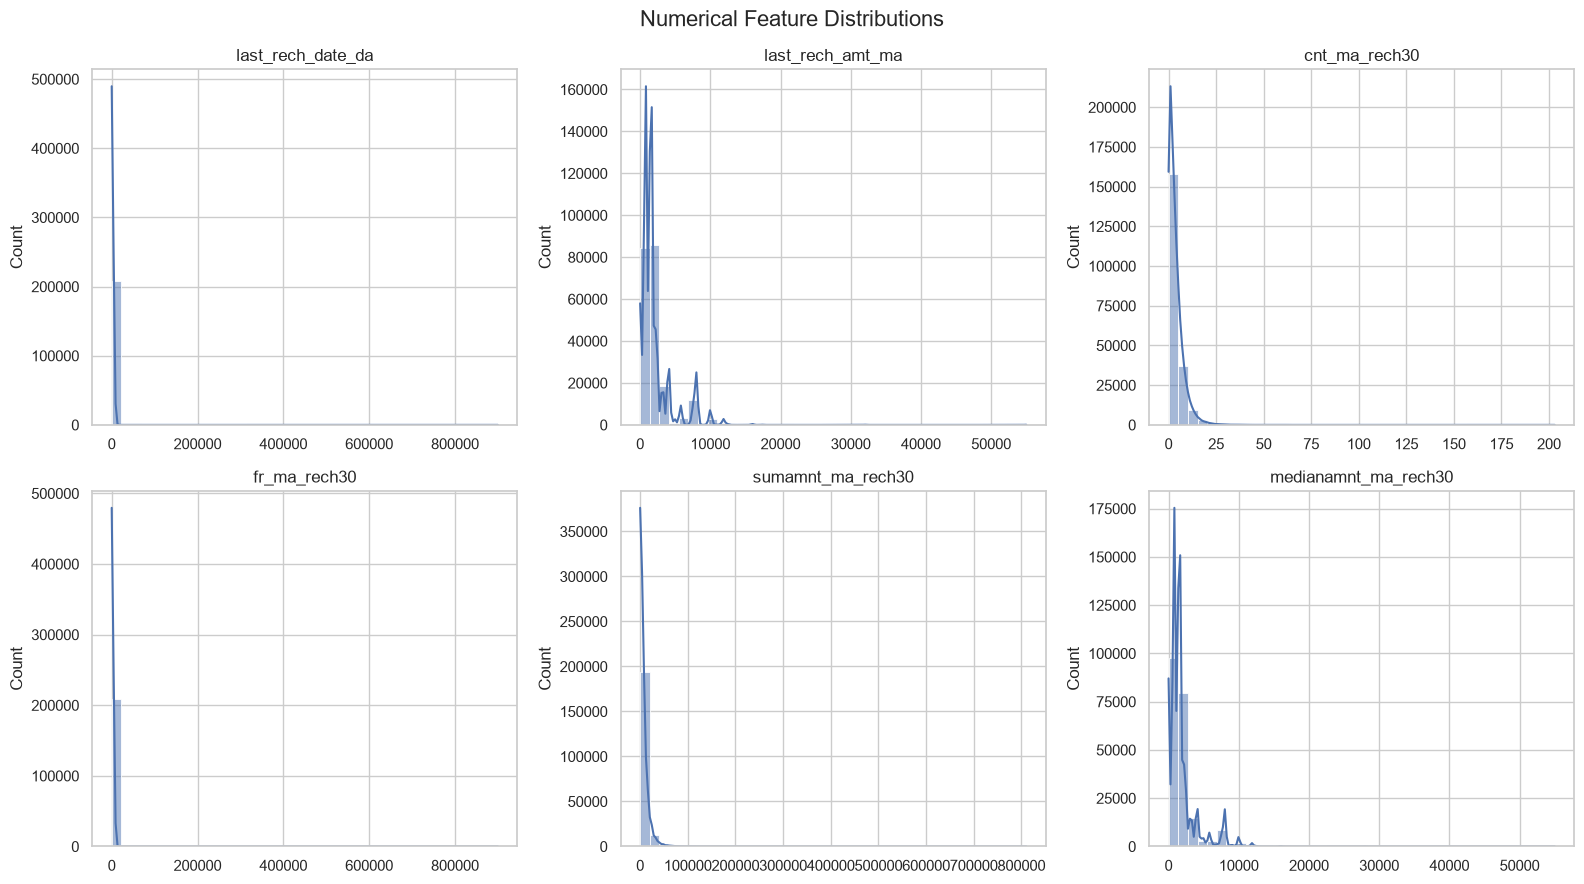

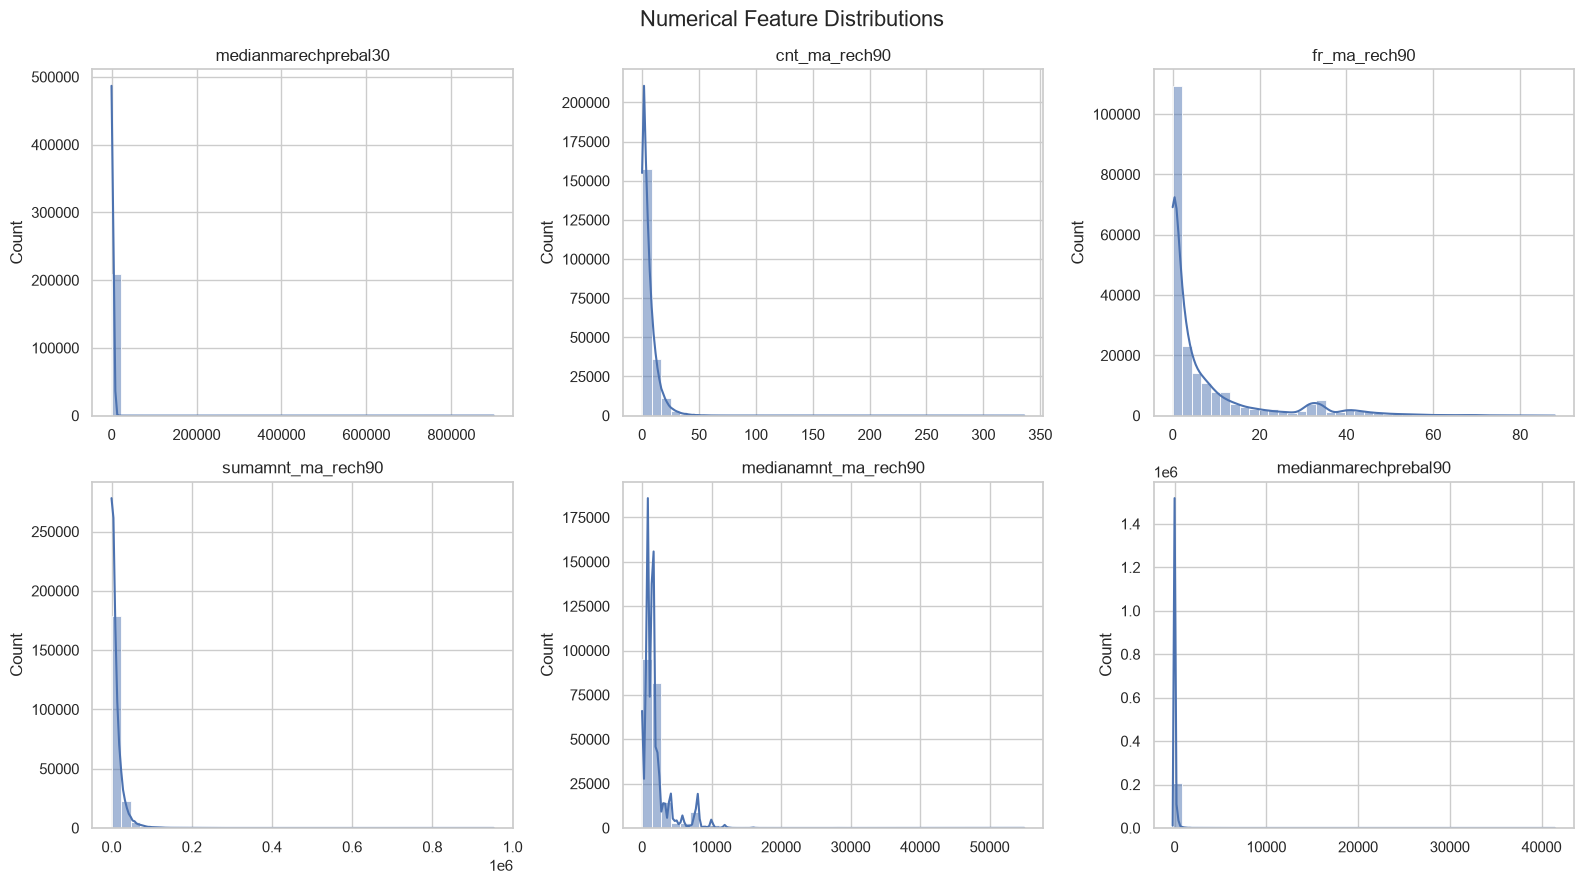

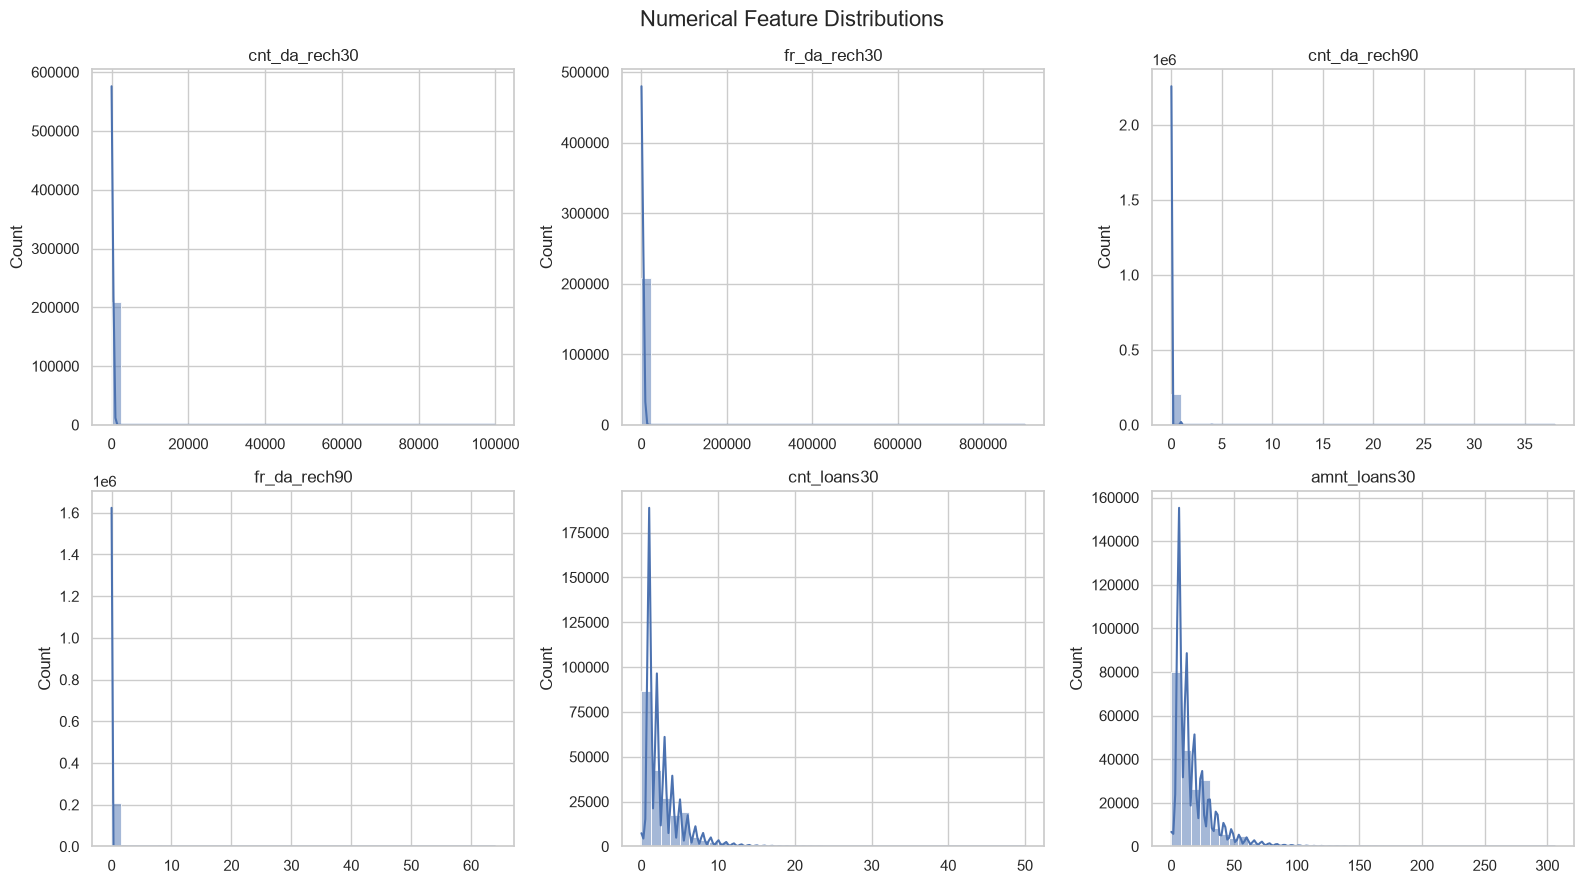

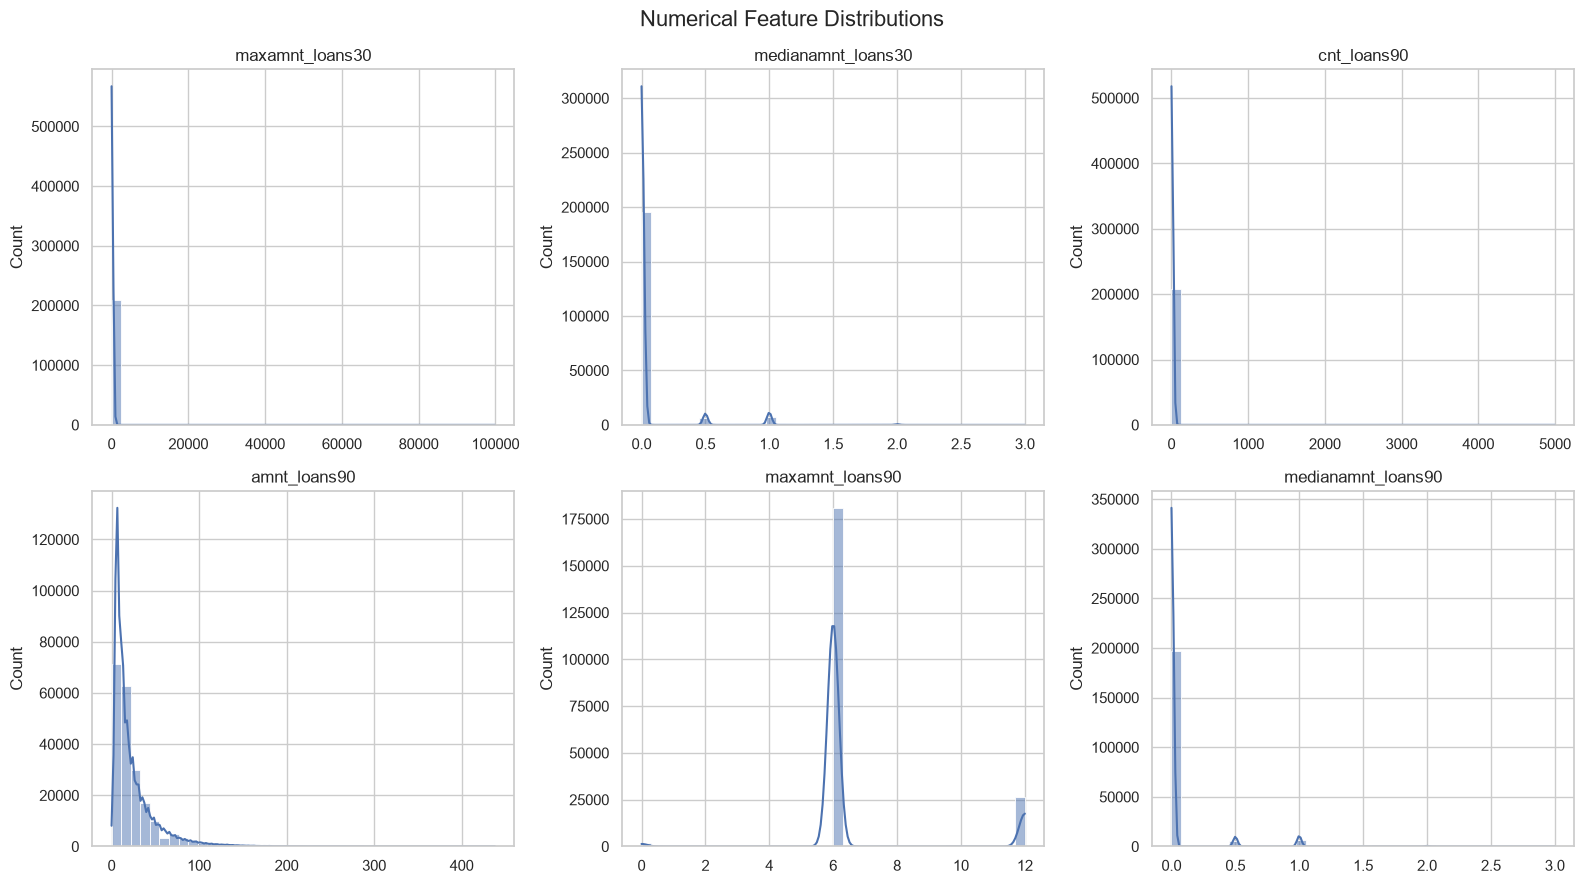

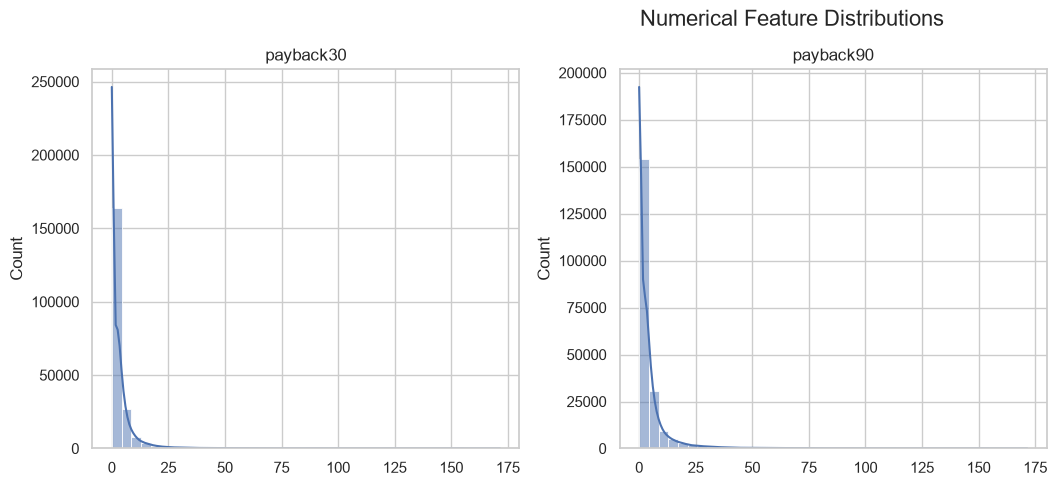

In [22]:
# Plot distributions of numerical features

for i in range(0, len(numerical_features), 6):
    
    batch = numerical_features[i:i+6]
    
    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(16, 9)
    )
    
    axes = axes.flatten()
    
    for ax, column in zip(axes, batch):
        sns.histplot(
            df[column],
            bins=40,
            kde=True,
            ax=ax
        )
        
        ax.set_title(column)
        ax.set_xlabel("")
    
    # Hide unused axes
    for ax in axes[len(batch):]:
        ax.set_visible(False)
    
    plt.suptitle(
        "Numerical Feature Distributions",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()

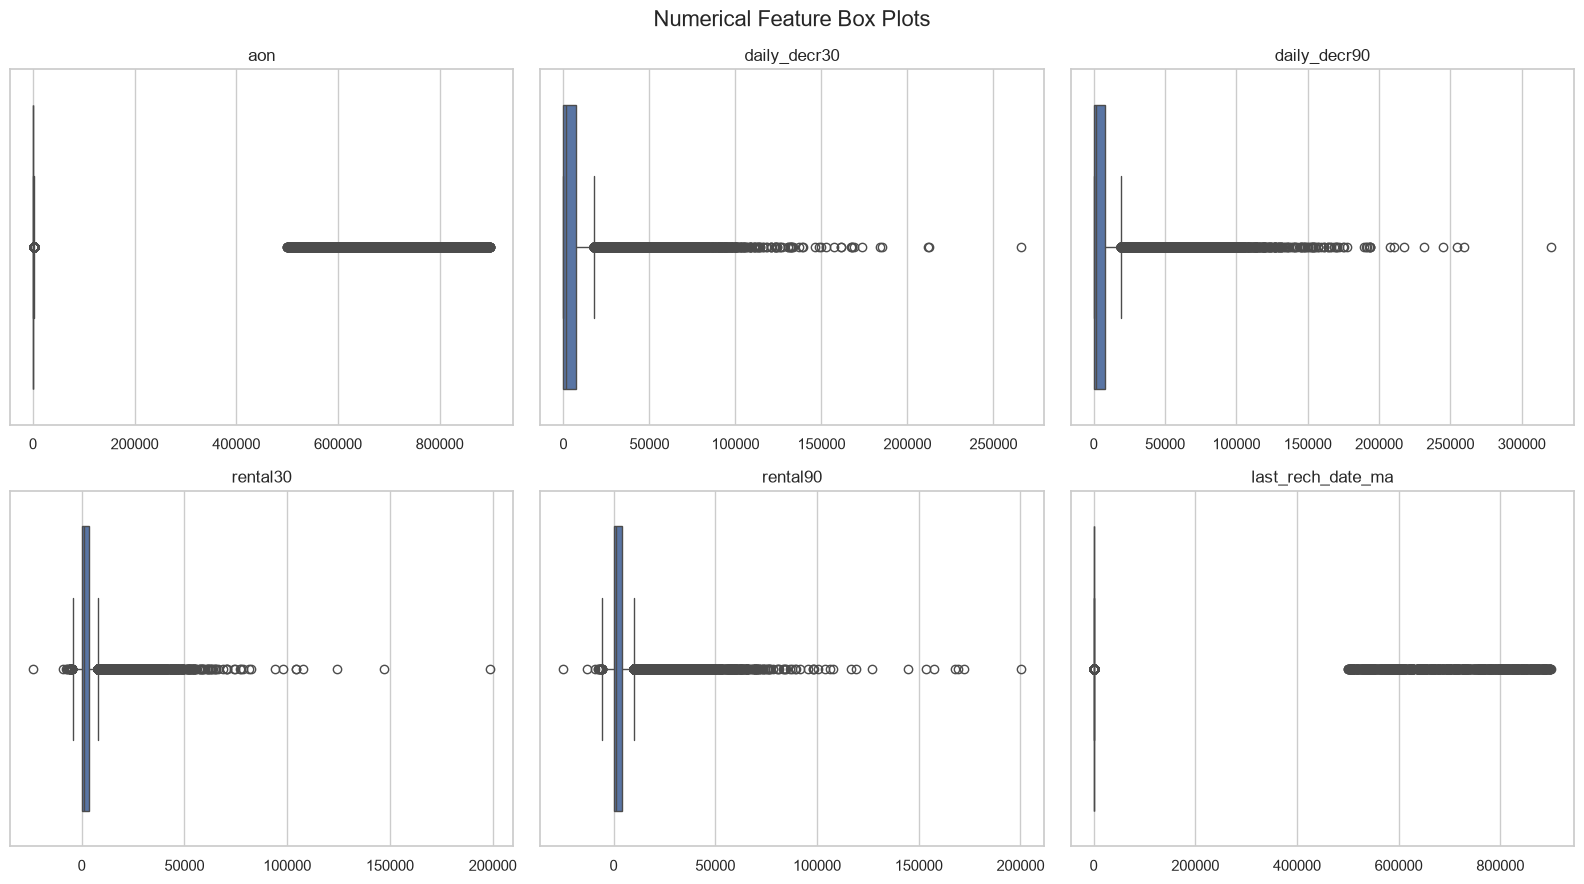

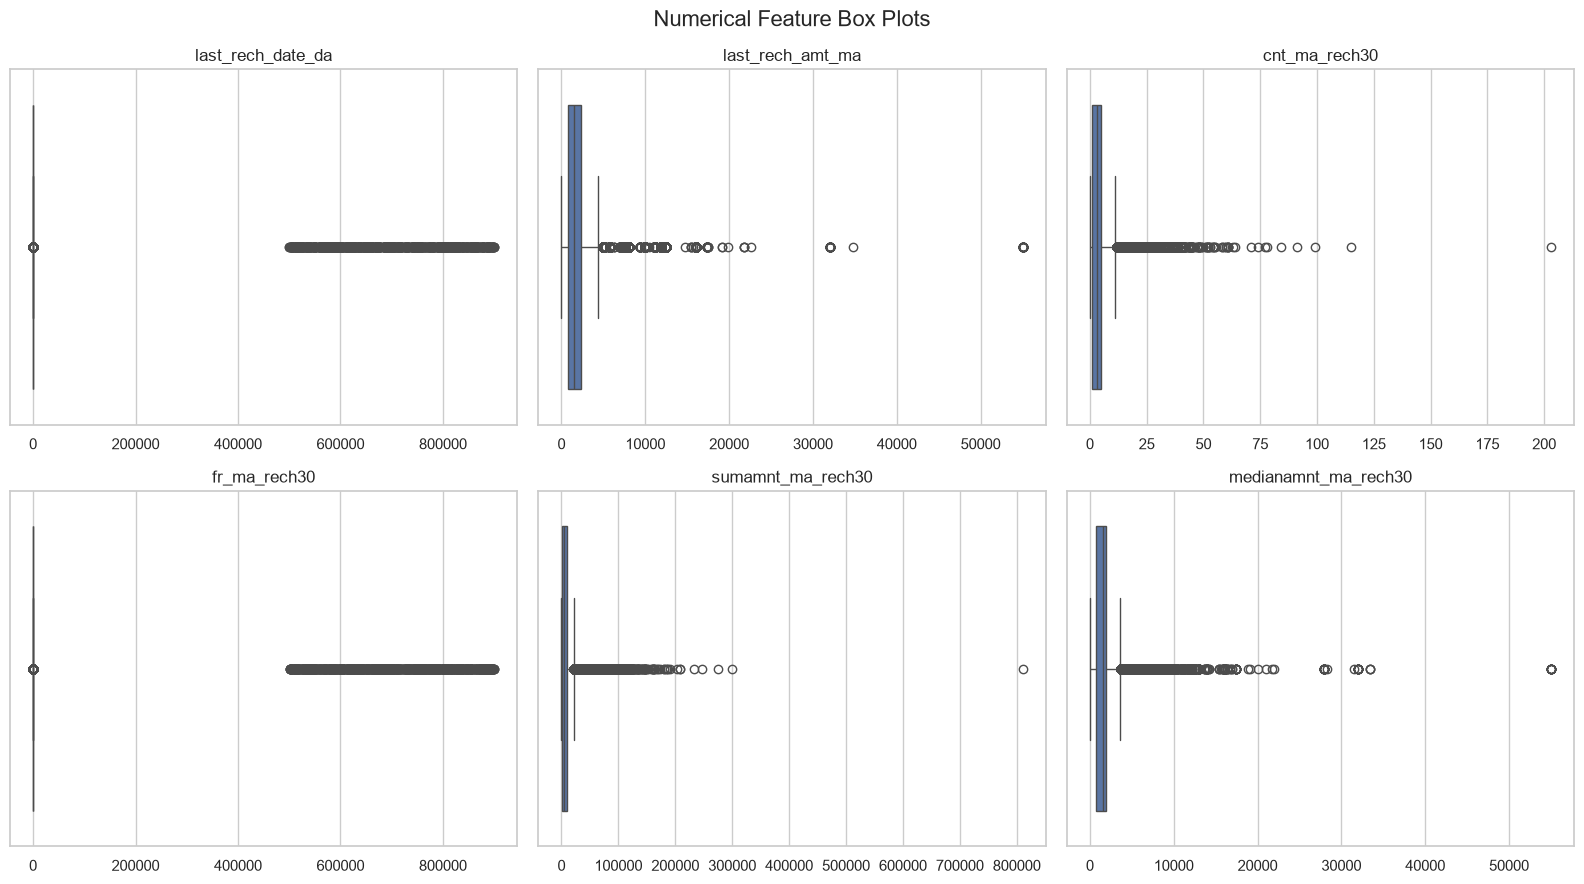

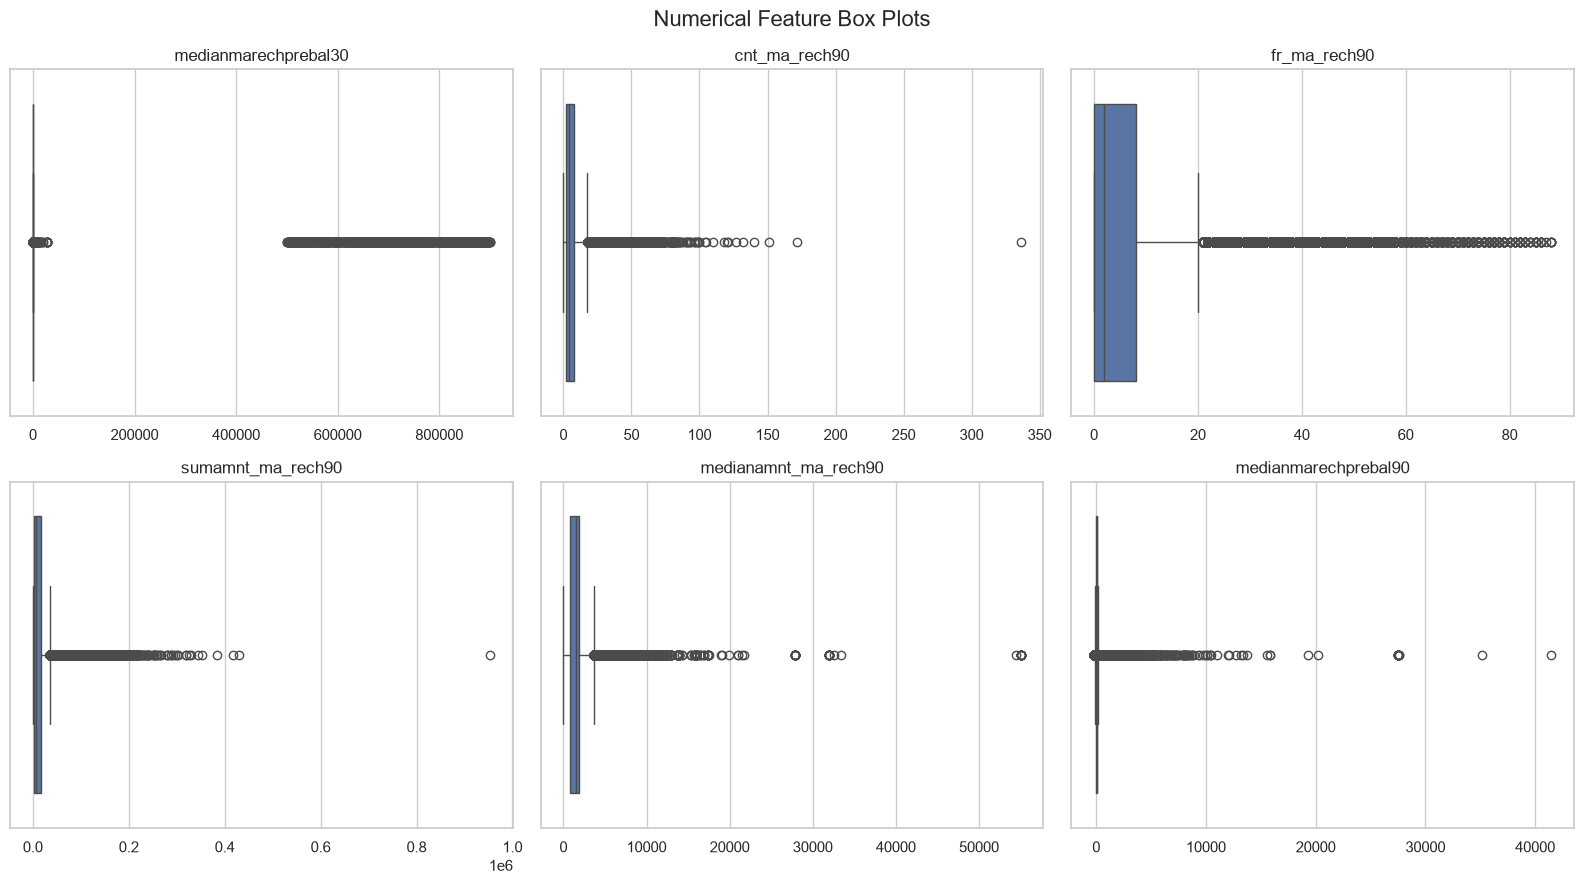

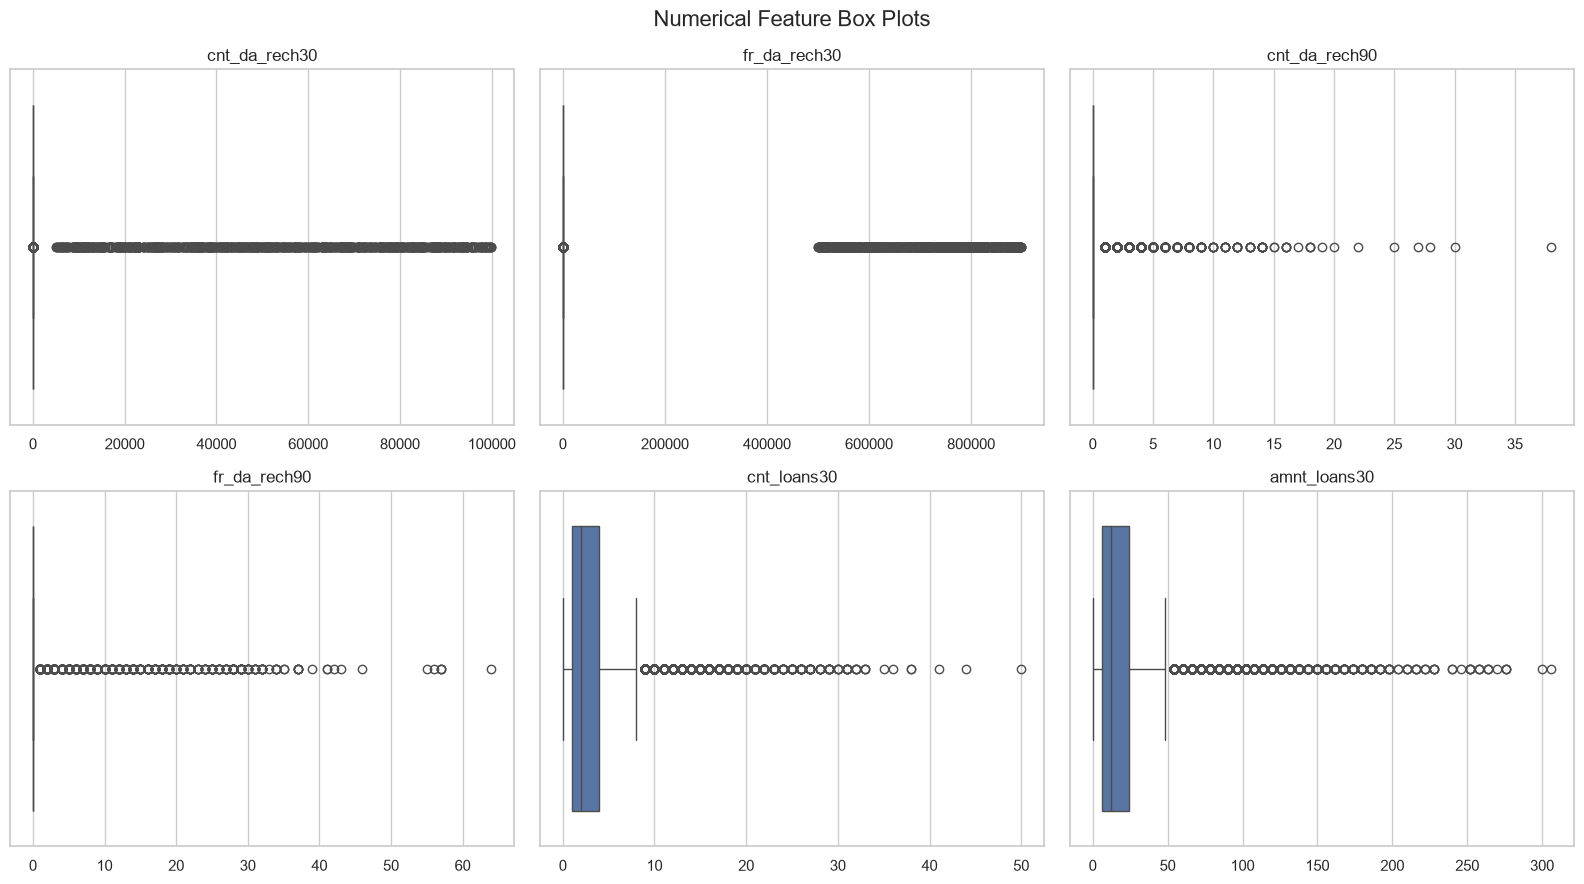

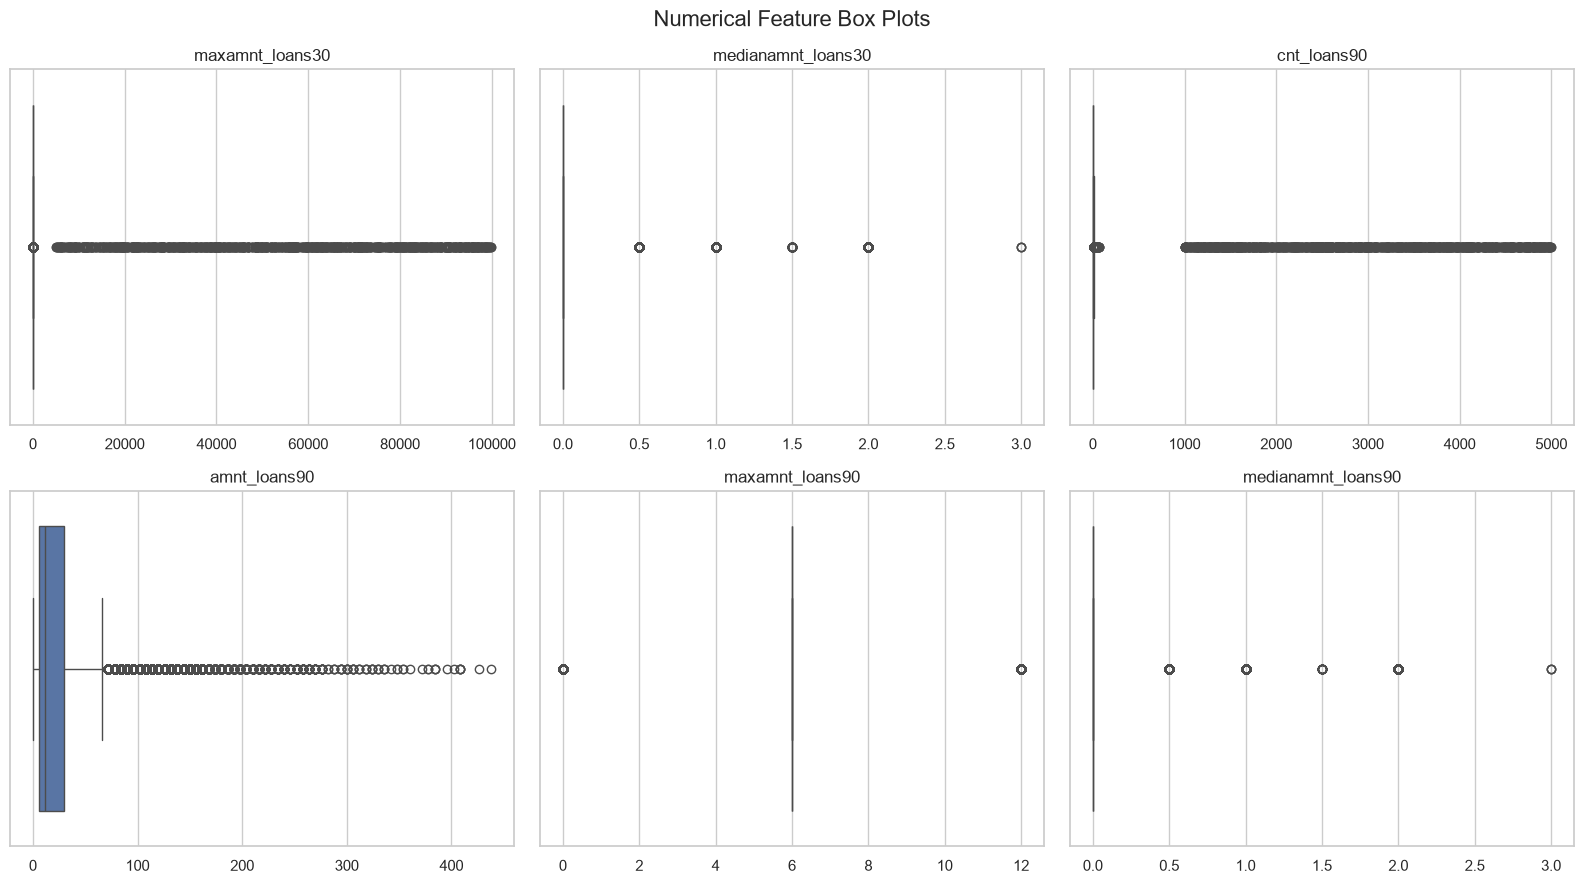

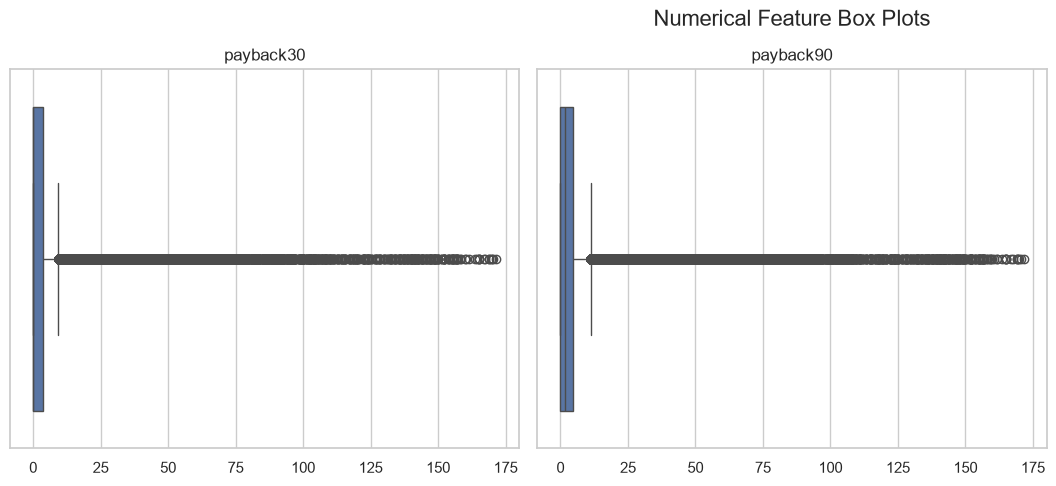

In [23]:
# Box plots for detecting potential outliers

for i in range(0, len(numerical_features), 6):
    
    batch = numerical_features[i:i+6]
    
    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(16, 9)
    )
    
    axes = axes.flatten()
    
    for ax, column in zip(axes, batch):
        sns.boxplot(
            x=df[column],
            ax=ax
        )
        
        ax.set_title(column)
        ax.set_xlabel("")
    
    # Hide unused axes
    for ax in axes[len(batch):]:
        ax.set_visible(False)
    
    plt.suptitle(
        "Numerical Feature Box Plots",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()

In [24]:
# Identify highly skewed numerical features

skewness_summary = (
    df[numerical_features]
    .skew()
    .sort_values(key=lambda x: abs(x), ascending=False)
)

print("Features ordered by absolute skewness:")

display(
    skewness_summary.to_frame("Skewness")
)

Features ordered by absolute skewness:


,Skewness
medianmarechprebal90,44.880503
fr_da_rech90,28.988083
cnt_da_rech90,27.267278
cnt_da_rech30,17.818364
maxamnt_loans30,17.658052
cnt_loans90,16.594408
medianmarechprebal30,16.475904
last_rech_date_ma,16.429941
last_rech_date_da,16.315431
fr_da_rech30,16.261558


In [25]:
# Identify features with large differences between
# the 99th percentile and median

extreme_value_summary = pd.DataFrame({
    "Median": df[numerical_features].median(),
    "99th_Percentile": df[numerical_features].quantile(0.99),
    "Maximum": df[numerical_features].max()
})

extreme_value_summary["Max_to_Median_Ratio"] = (
    extreme_value_summary["Maximum"] /
    extreme_value_summary["Median"].replace(0, np.nan)
)

display(
    extreme_value_summary.sort_values(
        "Max_to_Median_Ratio",
        ascending=False
    )
)

,Median,99th_Percentile,Maximum,Max_to_Median_Ratio
fr_ma_rech30,2.000000,26.000000,899853.109731,449926.554866
last_rech_date_ma,3.000000,54.000000,899991.527898,299997.175966
medianmarechprebal30,33.740000,1173.540000,899852.288305,26670.192303
maxamnt_loans30,6.000000,12.000000,99864.560864,16644.093477
cnt_loans90,2.000000,23.000000,4997.517944,2498.758972
aon,525.000000,2281.000000,899968.078244,1714.224911
medianmarechprebal90,36.000000,840.196400,41456.500000,1151.569444
daily_decr90,1500.000000,49967.383600,320630.000000,213.753333
rental30,1083.570000,19461.376400,198926.110000,183.583995
daily_decr30,1469.175667,41730.440000,265926.000000,181.003542


## 6. Feature Distribution by Repayment Label

This analysis compares numerical feature distributions across the two repayment classes.

The objective is to identify whether customer financial behavior, recharge activity, loan activity, and repayment characteristics differ between:

- Label 0 — Minority repayment class
- Label 1 — Majority repayment class

Class-wise summary statistics and box plots are used to identify potentially informative features and differences between the target classes.

In [26]:
# Calculate class-wise median values

class_median = df.groupby("label")[numerical_features].median().T

class_median.columns = [
    "Label_0_Median",
    "Label_1_Median"
]

class_median["Absolute_Difference"] = (
    class_median["Label_1_Median"] -
    class_median["Label_0_Median"]
).abs()

class_median = class_median.sort_values(
    "Absolute_Difference",
    ascending=False
)

display(class_median)

,Label_0_Median,Label_1_Median,Absolute_Difference
sumamnt_ma_rech90,1539.0000,8473.000,6934.0000
sumamnt_ma_rech30,773.0000,5498.000,4725.0000
daily_decr90,35.1950,2190.950,2155.7550
daily_decr30,33.4475,2127.695,2094.2475
rental90,659.9400,1443.330,783.3900
medianamnt_ma_rech30,770.0000,1539.000,769.0000
last_rech_amt_ma,770.0000,1539.000,769.0000
medianamnt_ma_rech90,773.0000,1539.000,766.0000
rental30,591.6200,1152.070,560.4500
aon,399.0000,542.000,143.0000


In [27]:
# Calculate class-wise mean values

class_mean = df.groupby("label")[numerical_features].mean().T

class_mean.columns = [
    "Label_0_Mean",
    "Label_1_Mean"
]

class_mean["Absolute_Difference"] = (
    class_mean["Label_1_Mean"] -
    class_mean["Label_0_Mean"]
).abs()

class_mean = class_mean.sort_values(
    "Absolute_Difference",
    ascending=False
)

display(class_mean)

,Label_0_Mean,Label_1_Mean,Absolute_Difference
sumamnt_ma_rech90,3210.102783,13706.395778,10496.292996
sumamnt_ma_rech30,2258.849629,8481.191767,6222.342138
daily_decr90,1278.817736,6767.646423,5488.828687
daily_decr30,1272.376756,5967.455497,4695.078741
rental90,2329.486376,3647.985363,1318.498988
last_rech_amt_ma,1237.045830,2182.462408,945.416578
aon,7070.818612,6160.425280,910.393332
medianamnt_ma_rech30,1036.967185,1923.474317,886.507132
medianamnt_ma_rech90,1198.435135,1959.607547,761.172412
rental30,2029.914812,2787.095360,757.180548


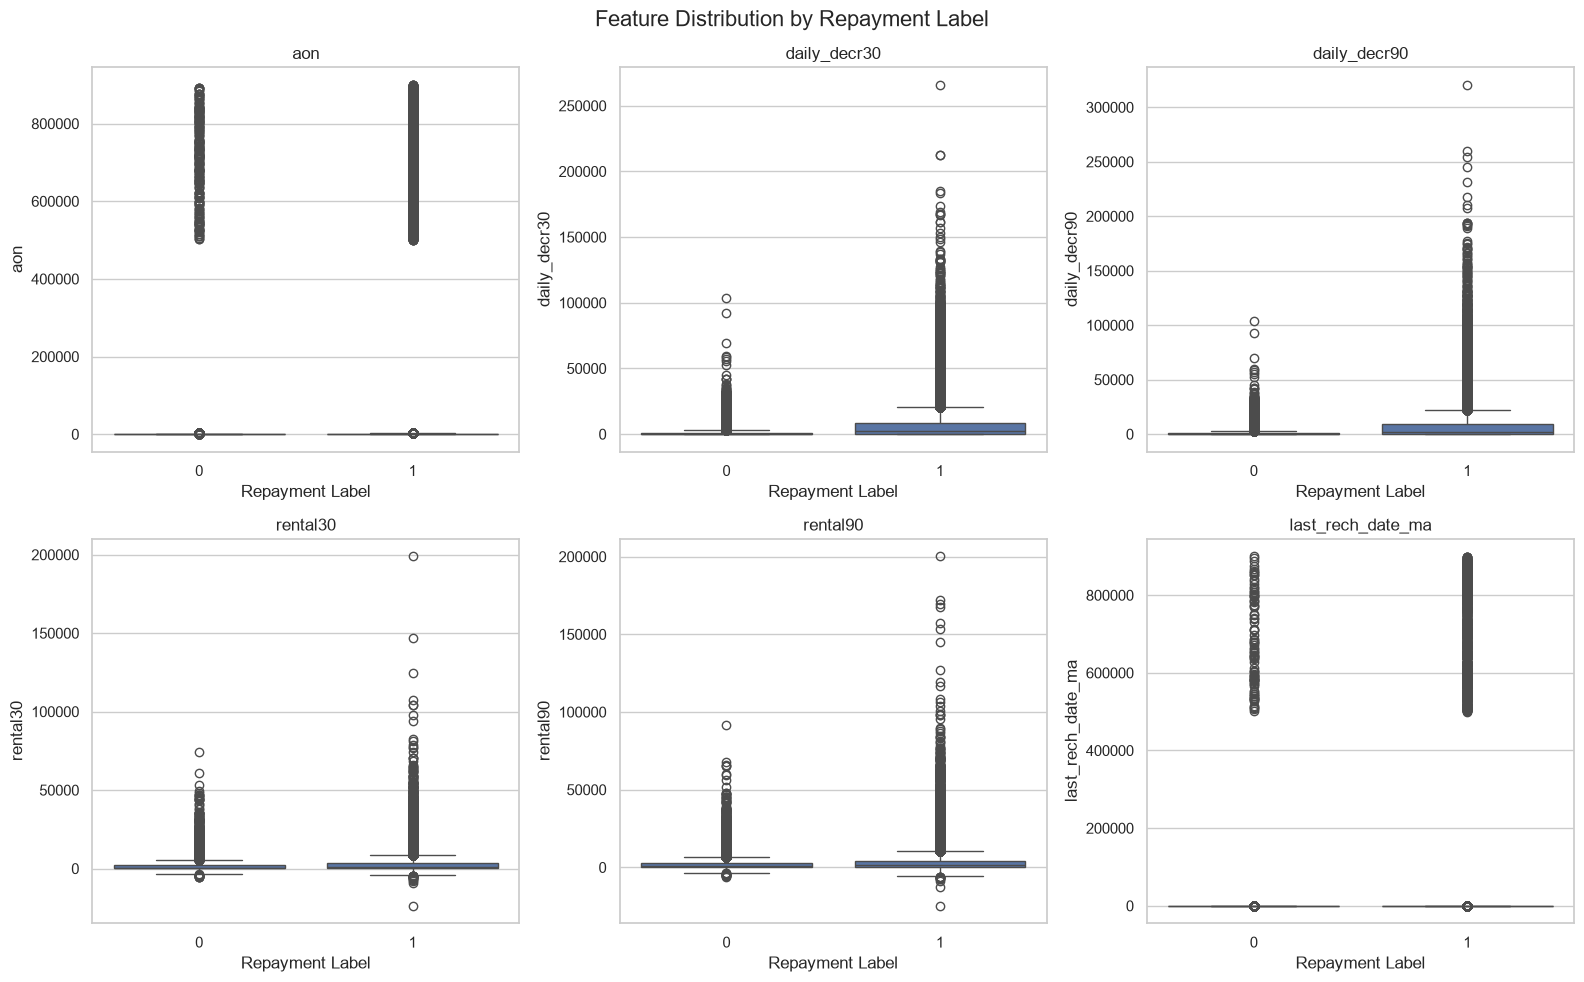

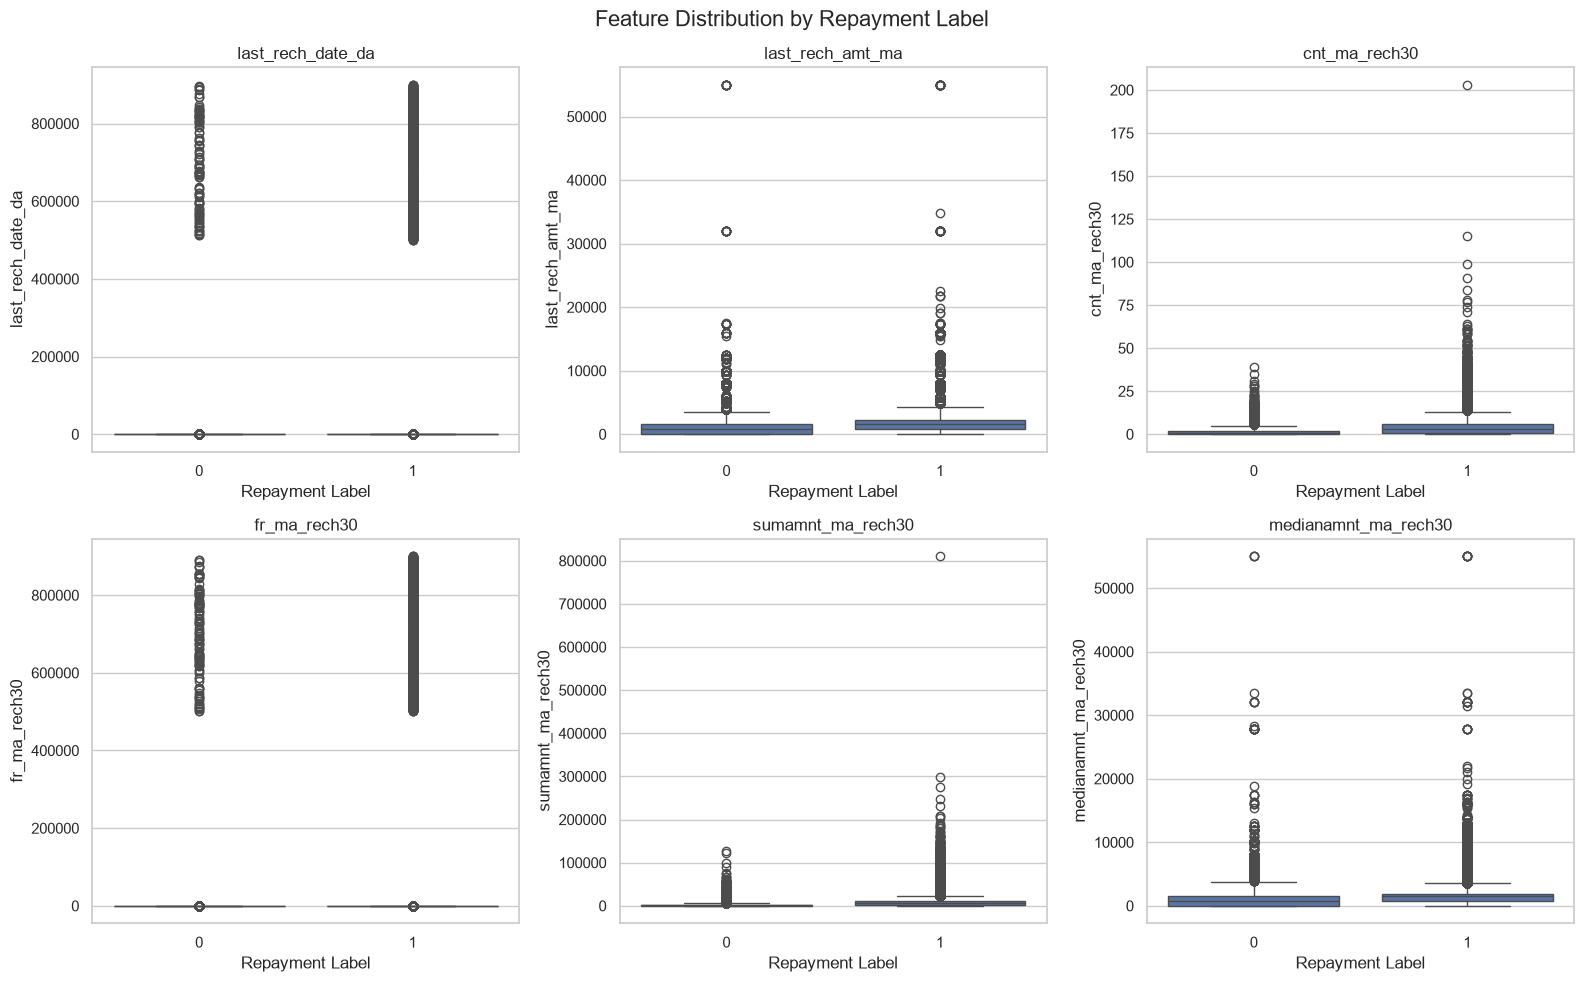

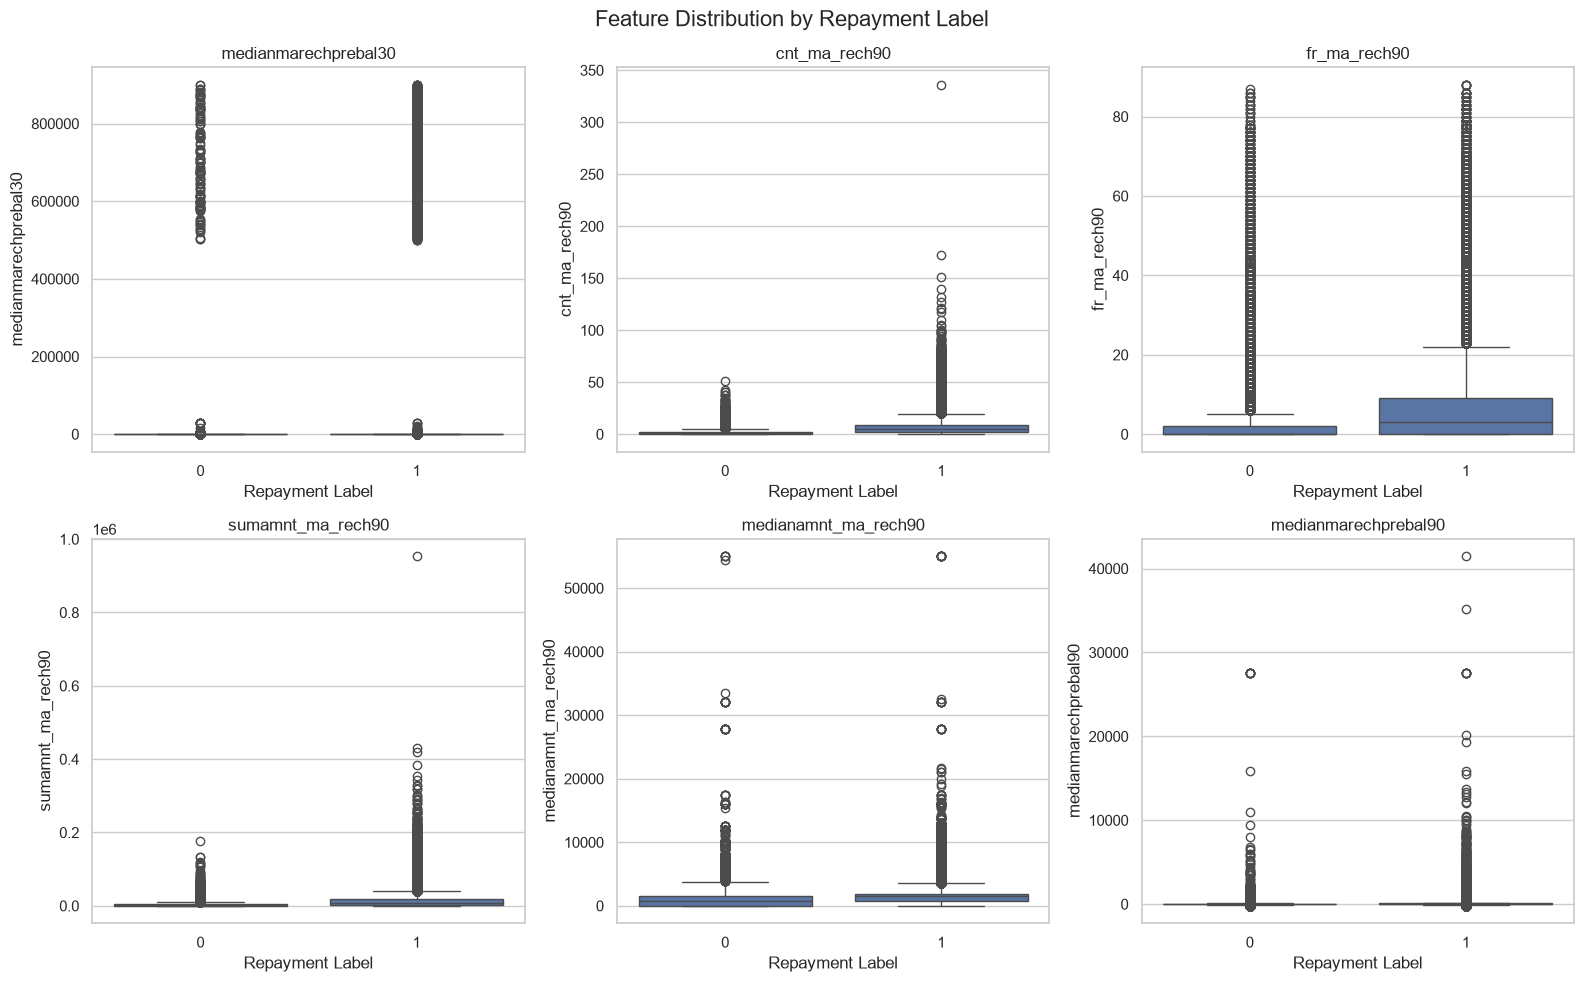

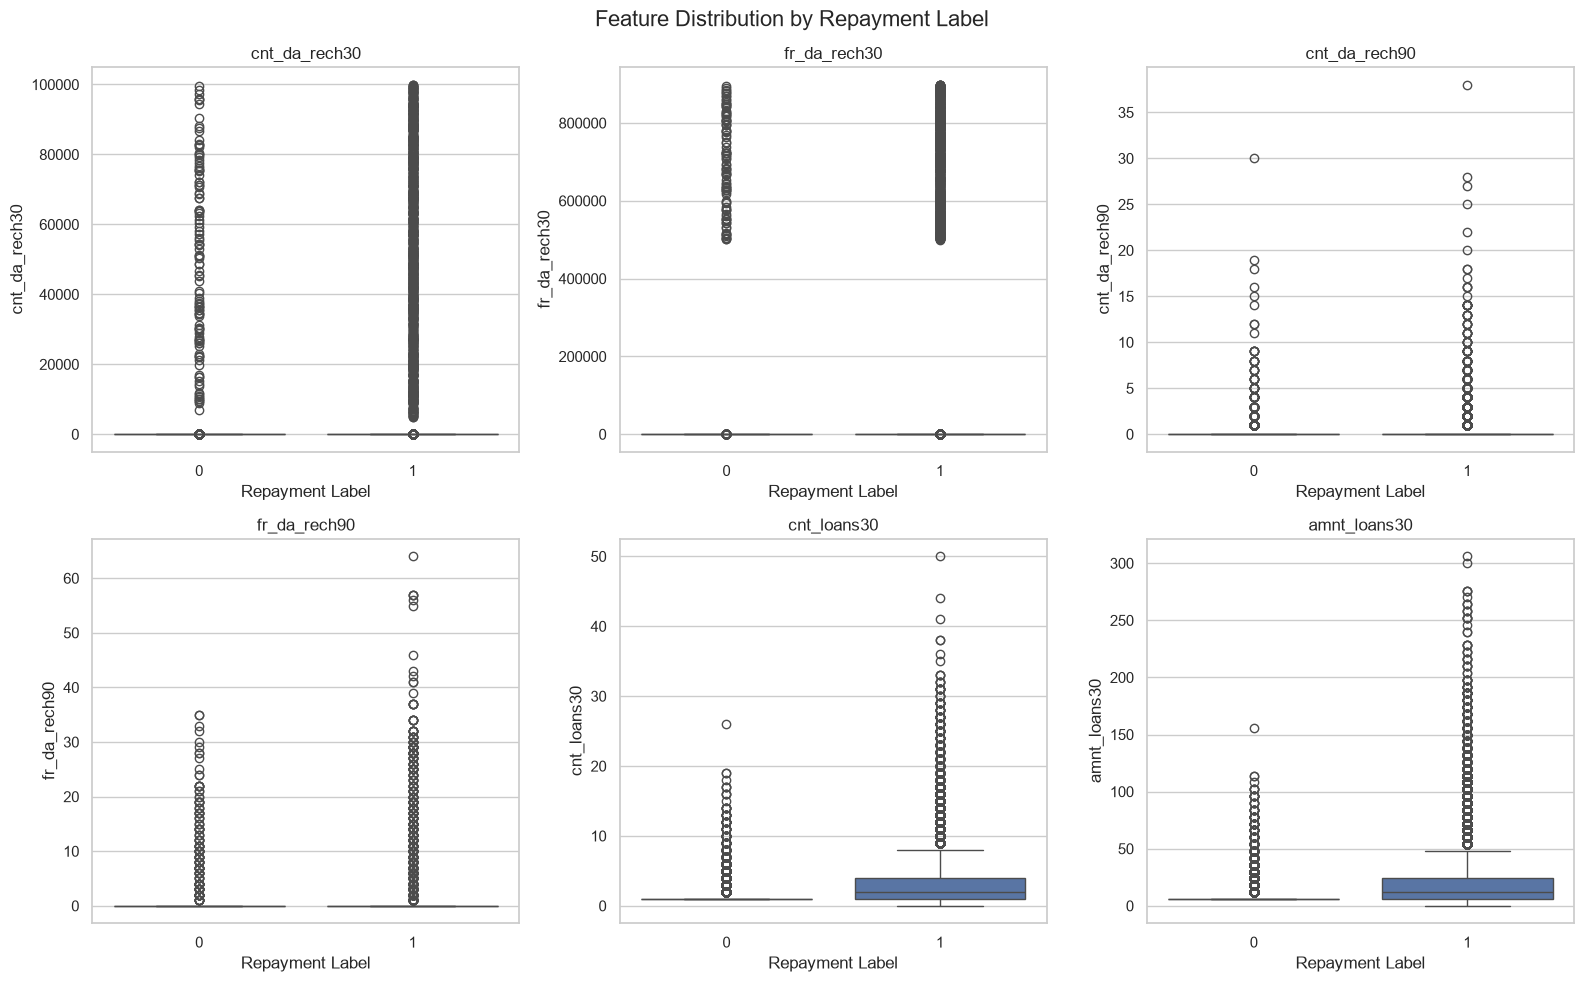

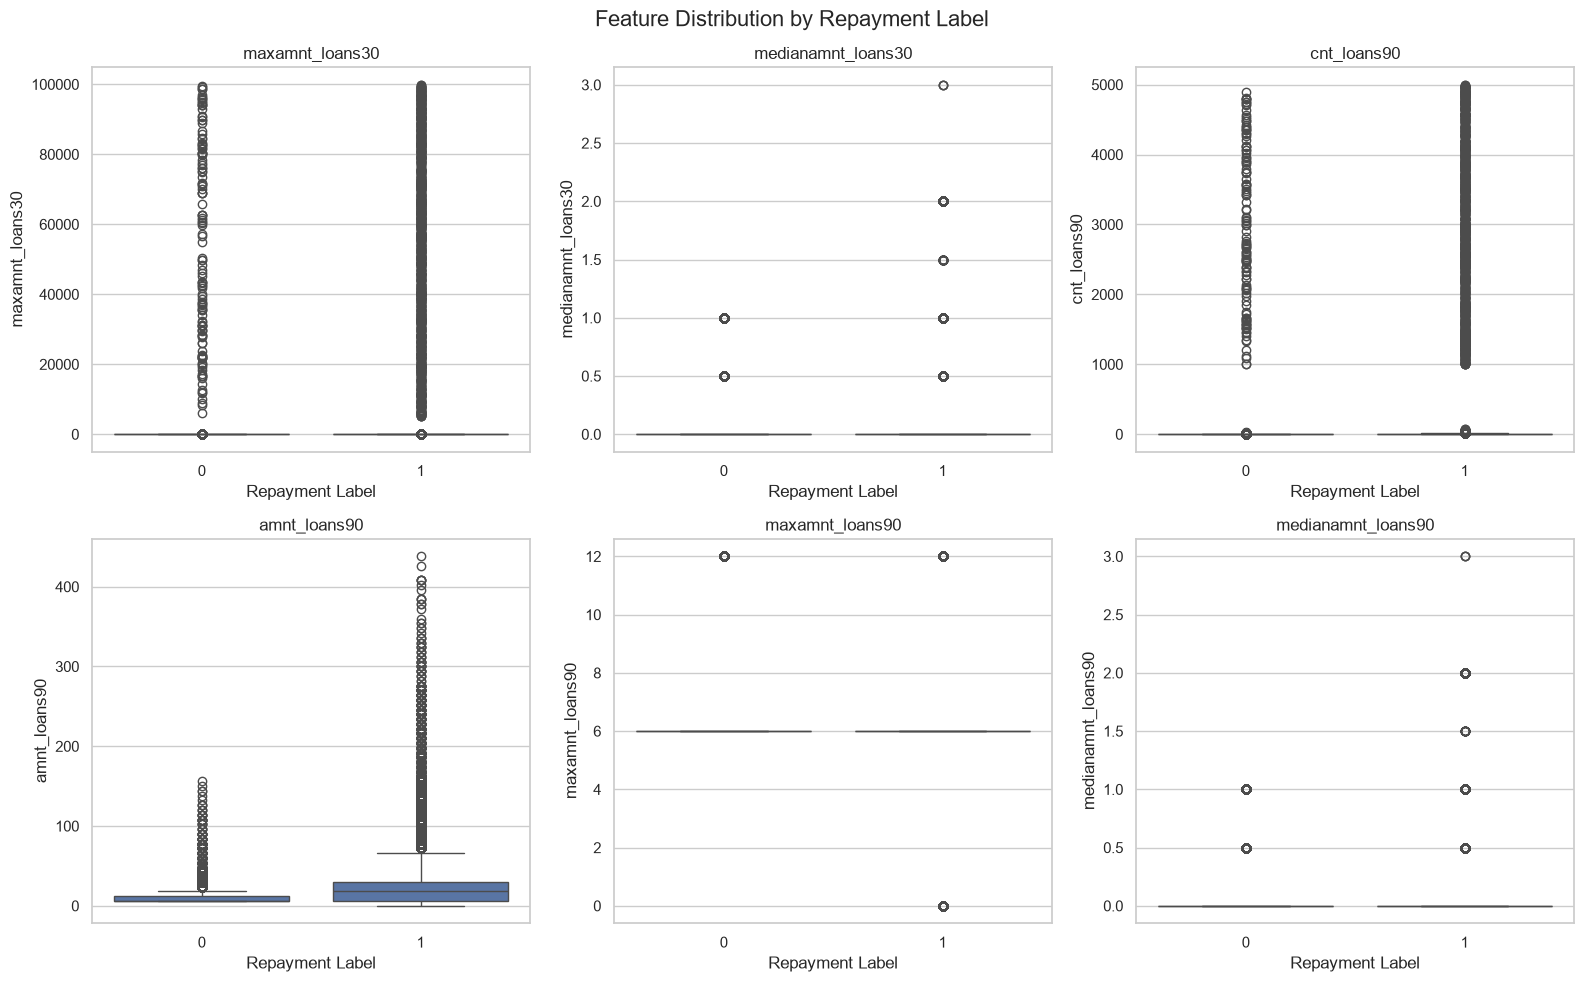

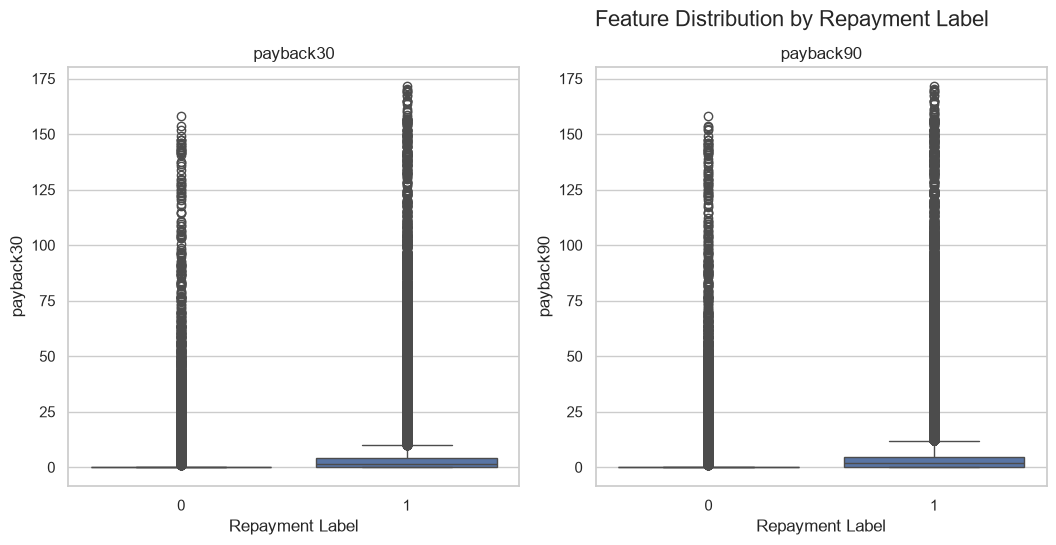

In [28]:
# Compare feature distributions across repayment labels

for i in range(0, len(numerical_features), 6):

    batch = numerical_features[i:i+6]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(16, 10)
    )

    axes = axes.flatten()

    for ax, column in zip(axes, batch):

        sns.boxplot(
            data=df,
            x="label",
            y=column,
            ax=ax
        )

        ax.set_title(column)
        ax.set_xlabel("Repayment Label")

    # Hide unused axes
    for ax in axes[len(batch):]:
        ax.set_visible(False)

    plt.suptitle(
        "Feature Distribution by Repayment Label",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [29]:
# Compare class medians using relative difference

comparison = pd.DataFrame(index=numerical_features)

comparison["Label_0_Median"] = (
    df[df["label"] == 0][numerical_features].median()
)

comparison["Label_1_Median"] = (
    df[df["label"] == 1][numerical_features].median()
)

comparison["Difference"] = (
    comparison["Label_1_Median"] -
    comparison["Label_0_Median"]
)

comparison["Absolute_Difference"] = (
    comparison["Difference"].abs()
)

display(
    comparison.sort_values(
        "Absolute_Difference",
        ascending=False
    )
)

,Label_0_Median,Label_1_Median,Difference,Absolute_Difference
sumamnt_ma_rech90,1539.0000,8473.000,6934.0000,6934.0000
sumamnt_ma_rech30,773.0000,5498.000,4725.0000,4725.0000
daily_decr90,35.1950,2190.950,2155.7550,2155.7550
daily_decr30,33.4475,2127.695,2094.2475,2094.2475
rental90,659.9400,1443.330,783.3900,783.3900
medianamnt_ma_rech30,770.0000,1539.000,769.0000,769.0000
last_rech_amt_ma,770.0000,1539.000,769.0000,769.0000
medianamnt_ma_rech90,773.0000,1539.000,766.0000,766.0000
rental30,591.6200,1152.070,560.4500,560.4500
aon,399.0000,542.000,143.0000,143.0000


In [30]:
# Calculate correlation between numerical features and target

target_correlation = (
    df[numerical_features + ["label"]]
    .corr()["label"]
    .drop("label")
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

target_correlation_df = target_correlation.to_frame(
    name="Correlation_with_Label"
)

display(target_correlation_df)

,Correlation_with_Label
cnt_ma_rech30,0.237331
cnt_ma_rech90,0.236392
sumamnt_ma_rech90,0.205793
sumamnt_ma_rech30,0.202828
amnt_loans90,0.199788
amnt_loans30,0.197272
cnt_loans30,0.196283
daily_decr30,0.168298
daily_decr90,0.166150
medianamnt_ma_rech30,0.141490


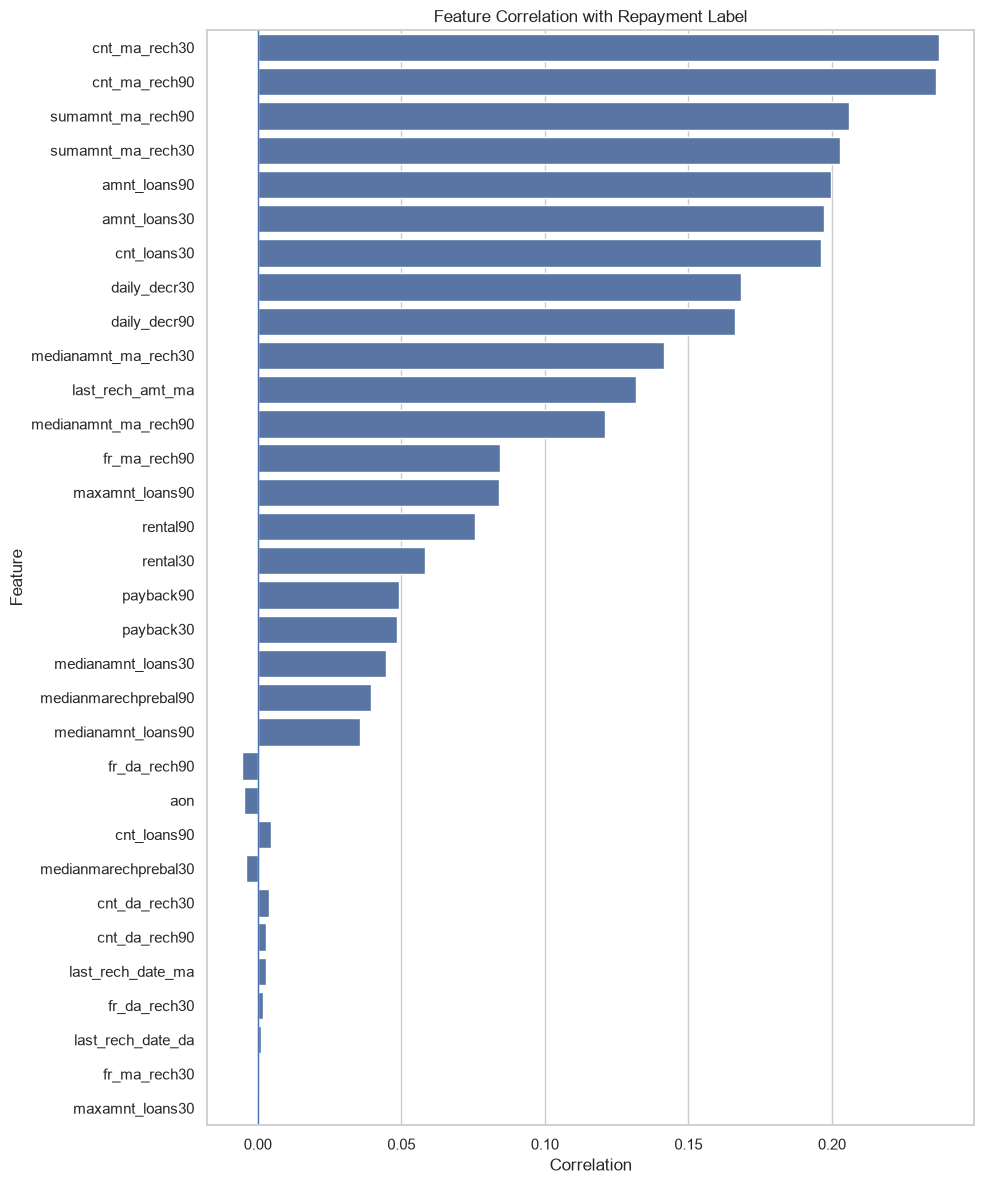

In [31]:
# Plot feature correlations with the repayment label

plt.figure(figsize=(10, 12))

sns.barplot(
    x=target_correlation.values,
    y=target_correlation.index
)

plt.axvline(
    0,
    linewidth=1
)

plt.title("Feature Correlation with Repayment Label")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 7. Correlation Analysis and Multicollinearity

This analysis examines relationships among numerical features.

The objectives are to:

- Identify highly correlated features.
- Detect possible multicollinearity.
- Understand relationships between 30-day and 90-day financial activity.
- Identify redundant features before model development.

Highly correlated features will be identified for further consideration during feature selection.

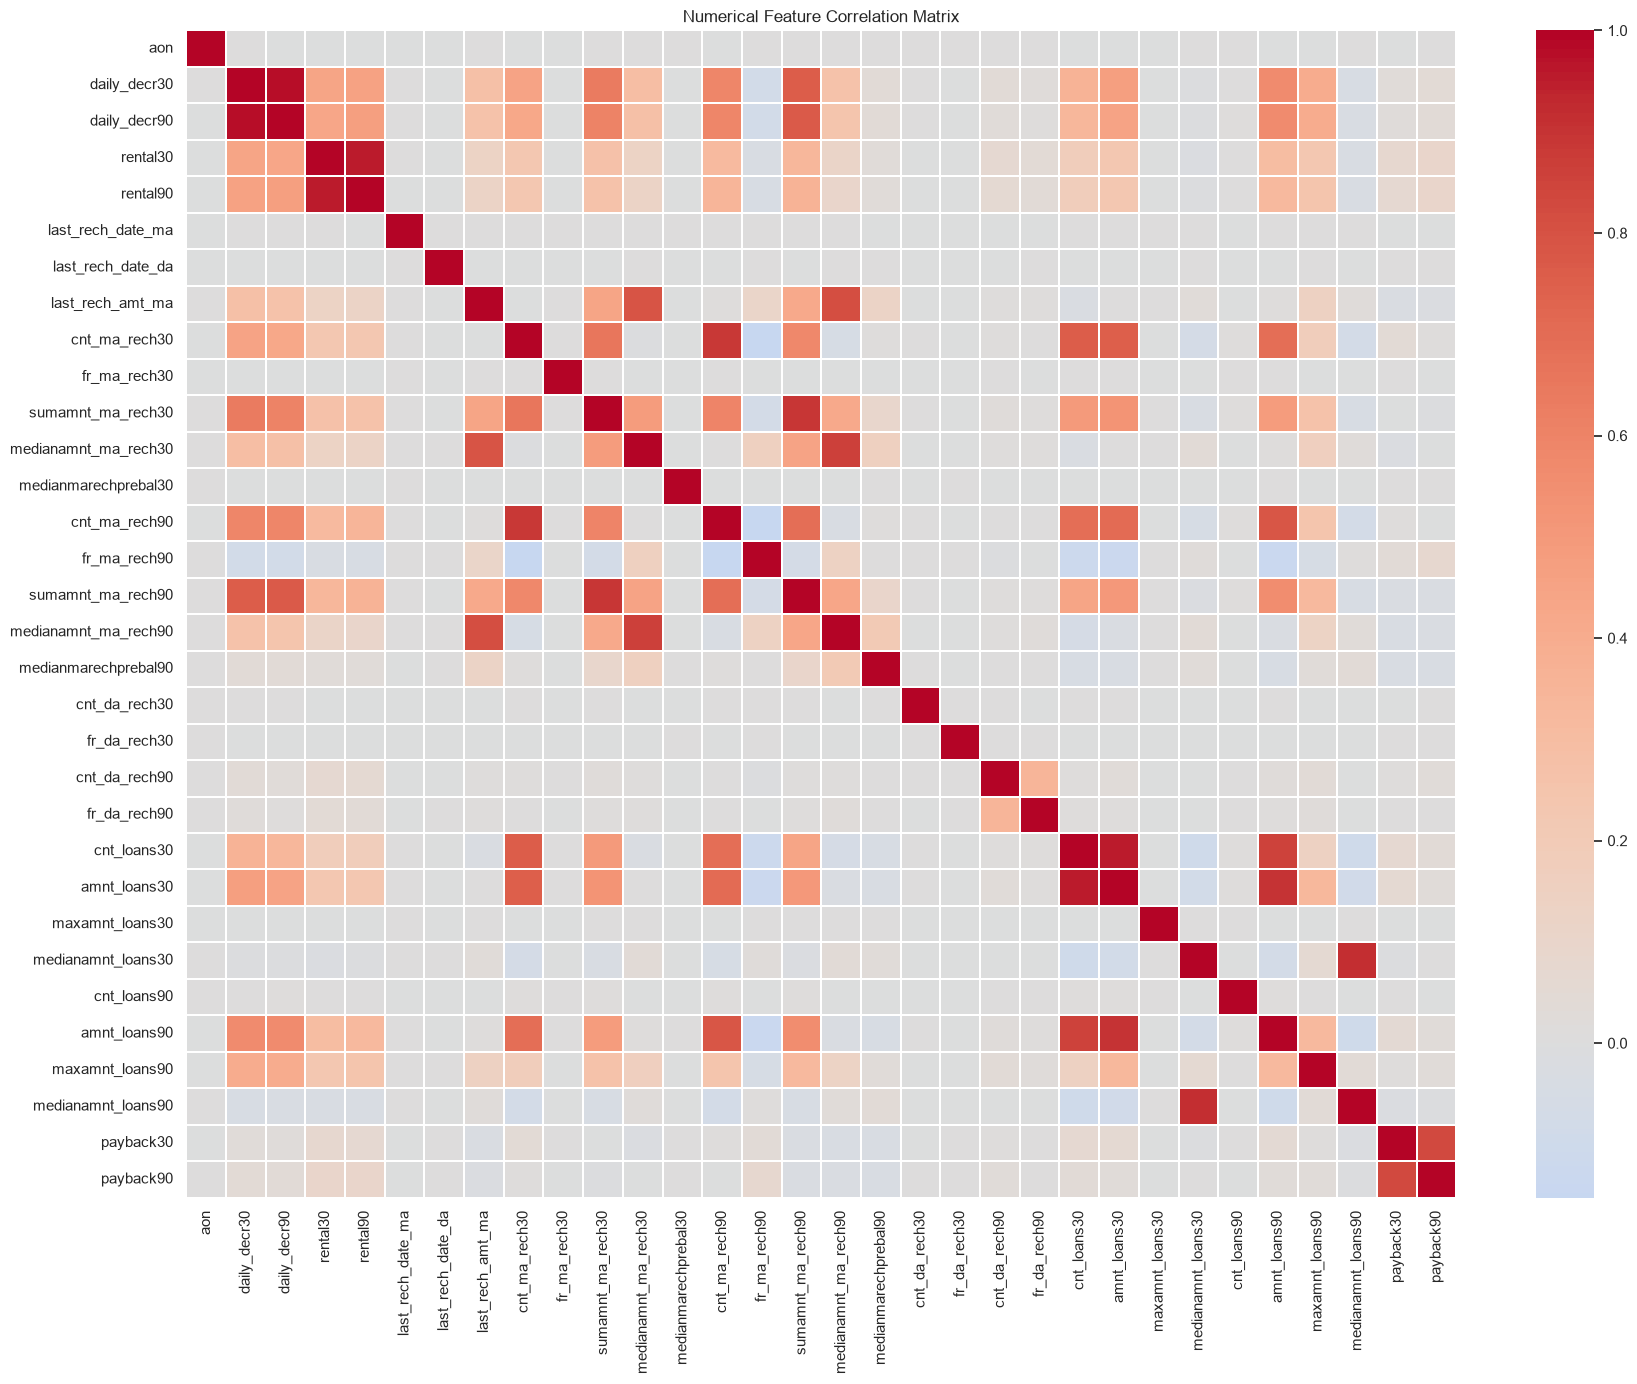

In [32]:
# Calculate correlation matrix

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [33]:
# Find highly correlated feature pairs

corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

high_corr_pairs = (
    corr_pairs[
        corr_pairs["Correlation"].abs() >= 0.80
    ]
    .sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )
)

display(high_corr_pairs)

,Feature_1,Feature_2,Correlation
34,daily_decr30,daily_decr90,0.977704
727,cnt_loans30,amnt_loans30,0.957742
100,rental30,rental90,0.955237
829,medianamnt_loans30,medianamnt_loans90,0.911604
763,amnt_loans30,amnt_loans90,0.897961
335,sumamnt_ma_rech30,sumamnt_ma_rech90,0.889989
269,cnt_ma_rech30,cnt_ma_rech90,0.886433
368,medianamnt_ma_rech30,medianamnt_ma_rech90,0.864846
731,cnt_loans30,amnt_loans90,0.852905
991,payback30,payback90,0.830363


In [34]:
# Display the strongest feature relationships

top_corr_pairs = (
    corr_pairs
    .sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )
    .head(20)
)

display(top_corr_pairs)

,Feature_1,Feature_2,Correlation
34,daily_decr30,daily_decr90,0.977704
727,cnt_loans30,amnt_loans30,0.957742
100,rental30,rental90,0.955237
829,medianamnt_loans30,medianamnt_loans90,0.911604
763,amnt_loans30,amnt_loans90,0.897961
335,sumamnt_ma_rech30,sumamnt_ma_rech90,0.889989
269,cnt_ma_rech30,cnt_ma_rech90,0.886433
368,medianamnt_ma_rech30,medianamnt_ma_rech90,0.864846
731,cnt_loans30,amnt_loans90,0.852905
991,payback30,payback90,0.830363


In [35]:
# Identify correlations based on absolute strength

high_corr_pairs["Absolute_Correlation"] = (
    high_corr_pairs["Correlation"].abs()
)

high_corr_pairs = high_corr_pairs.sort_values(
    "Absolute_Correlation",
    ascending=False
)

display(high_corr_pairs)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
34,daily_decr30,daily_decr90,0.977704,0.977704
727,cnt_loans30,amnt_loans30,0.957742,0.957742
100,rental30,rental90,0.955237,0.955237
829,medianamnt_loans30,medianamnt_loans90,0.911604,0.911604
763,amnt_loans30,amnt_loans90,0.897961,0.897961
335,sumamnt_ma_rech30,sumamnt_ma_rech90,0.889989,0.889989
269,cnt_ma_rech30,cnt_ma_rech90,0.886433,0.886433
368,medianamnt_ma_rech30,medianamnt_ma_rech90,0.864846,0.864846
731,cnt_loans30,amnt_loans90,0.852905,0.852905
991,payback30,payback90,0.830363,0.830363


## 8. Multicollinearity and Feature Selection Candidates

The correlation analysis identified several pairs of highly correlated
features.

A correlation threshold of 0.80 is used to identify potential
multicollinearity.

Highly correlated features may contain overlapping information.
However, features will not be removed automatically because both
30-day and 90-day behavioral information may be useful for predicting
loan repayment.

The identified features will be evaluated further before final
feature selection.

In [36]:
# Define correlation threshold

CORRELATION_THRESHOLD = 0.80

high_corr_pairs = (
    corr_pairs[
        corr_pairs["Correlation"].abs() >= CORRELATION_THRESHOLD
    ]
    .sort_values(
        "Correlation",
        key=abs,
        ascending=False
    )
)

print("Correlation threshold:", CORRELATION_THRESHOLD)
print("Number of highly correlated pairs:", len(high_corr_pairs))

display(high_corr_pairs)

Correlation threshold: 0.8
Number of highly correlated pairs: 11


,Feature_1,Feature_2,Correlation
34,daily_decr30,daily_decr90,0.977704
727,cnt_loans30,amnt_loans30,0.957742
100,rental30,rental90,0.955237
829,medianamnt_loans30,medianamnt_loans90,0.911604
763,amnt_loans30,amnt_loans90,0.897961
335,sumamnt_ma_rech30,sumamnt_ma_rech90,0.889989
269,cnt_ma_rech30,cnt_ma_rech90,0.886433
368,medianamnt_ma_rech30,medianamnt_ma_rech90,0.864846
731,cnt_loans30,amnt_loans90,0.852905
991,payback30,payback90,0.830363


In [37]:
# Extract all features involved in high correlations

high_corr_features = sorted(
    set(high_corr_pairs["Feature_1"])
    .union(set(high_corr_pairs["Feature_2"]))
)

print("Features involved in high correlations:")
print()

for i, feature in enumerate(high_corr_features, 1):
    print(f"{i:2}. {feature}")

print()
print("Number of candidate features:", len(high_corr_features))

Features involved in high correlations:

 1. amnt_loans30
 2. amnt_loans90
 3. cnt_loans30
 4. cnt_ma_rech30
 5. cnt_ma_rech90
 6. daily_decr30
 7. daily_decr90
 8. last_rech_amt_ma
 9. medianamnt_loans30
10. medianamnt_loans90
11. medianamnt_ma_rech30
12. medianamnt_ma_rech90
13. payback30
14. payback90
15. rental30
16. rental90
17. sumamnt_ma_rech30
18. sumamnt_ma_rech90

Number of candidate features: 18


In [38]:
# Calculate correlation of candidate features with repayment label

target_correlations = (
    df[high_corr_features + ["label"]]
    .corr()["label"]
    .drop("label")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlation_table = pd.DataFrame({
    "Feature": target_correlations.index,
    "Target_Correlation": target_correlations.values,
    "Absolute_Target_Correlation": target_correlations.abs().values
})

display(target_correlation_table)

,Feature,Target_Correlation,Absolute_Target_Correlation
0,cnt_ma_rech30,0.237331,0.237331
1,cnt_ma_rech90,0.236392,0.236392
2,sumamnt_ma_rech90,0.205793,0.205793
3,sumamnt_ma_rech30,0.202828,0.202828
4,amnt_loans90,0.199788,0.199788
5,amnt_loans30,0.197272,0.197272
6,cnt_loans30,0.196283,0.196283
7,daily_decr30,0.168298,0.168298
8,daily_decr90,0.166150,0.166150
9,medianamnt_ma_rech30,0.141490,0.141490


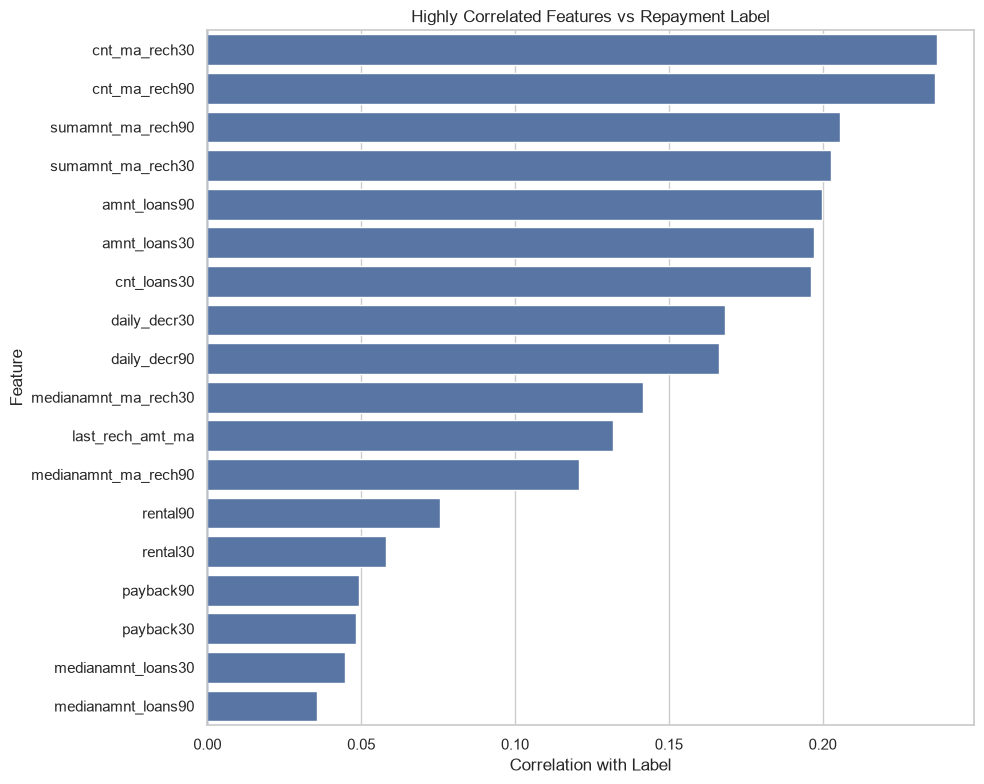

In [39]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=target_correlation_table,
    x="Target_Correlation",
    y="Feature"
)

plt.axvline(0, linewidth=1)
plt.title("Highly Correlated Features vs Repayment Label")
plt.xlabel("Correlation with Label")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [40]:
print("=" * 70)
print("MULTICOLLINEARITY SUMMARY")
print("=" * 70)

print(f"Total numerical features : {len(numerical_features)}")
print(f"Correlation threshold    : {CORRELATION_THRESHOLD}")
print(f"Highly correlated pairs  : {len(high_corr_pairs)}")
print(f"Candidate features       : {len(high_corr_features)}")

print("\nHighest correlation pair:")
if len(high_corr_pairs) > 0:
    top_pair = high_corr_pairs.iloc[0]
    print(
        f"{top_pair['Feature_1']} <-> "
        f"{top_pair['Feature_2']} : "
        f"{top_pair['Correlation']:.4f}"
    )

MULTICOLLINEARITY SUMMARY
Total numerical features : 32
Correlation threshold    : 0.8
Highly correlated pairs  : 11
Candidate features       : 18

Highest correlation pair:
daily_decr30 <-> daily_decr90 : 0.9777


## 9. Baseline Feature Importance

Feature importance is used to understand which variables contribute most
to repayment prediction.

A Random Forest model is trained as a baseline model using the cleaned
dataset. The resulting feature importances are used to rank the
predictive contribution of the input variables.

This step helps identify important features before final model training
and feature selection.

In [42]:
# Prepare features and target for baseline feature importance

X = df.drop(columns=["label", "pdate"])
y = df["label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of features:", X.shape[1])

Feature matrix shape: (209593, 32)
Target shape: (209593,)
Number of features: 32


In [43]:
from sklearn.ensemble import RandomForestClassifier

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

baseline_rf.fit(X, y)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": baseline_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance)

,Feature,Importance
0,daily_decr90,0.092588
1,daily_decr30,0.089902
2,sumamnt_ma_rech30,0.071769
3,sumamnt_ma_rech90,0.071421
4,cnt_ma_rech90,0.061139
5,aon,0.060425
6,rental90,0.054504
7,rental30,0.054394
8,payback90,0.043514
9,medianmarechprebal90,0.043195


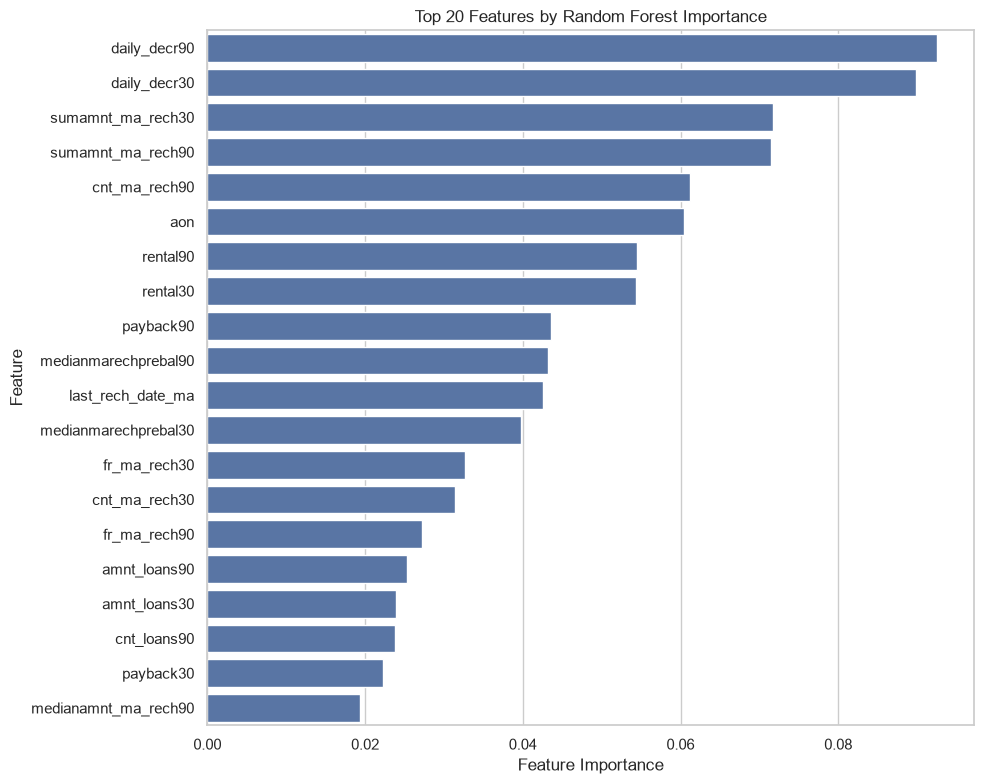

In [45]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features by Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 10. Feature Selection

Feature selection is performed to reduce unnecessary or weakly informative
variables while retaining important repayment behavior information.

The Random Forest feature importance results from the previous step are
used to identify informative features.

Features with very low importance are considered candidates for removal.
Highly correlated features are retained initially because they may contain
different 30-day and 90-day behavioral information.

The selected feature set will be evaluated during model training to verify
whether feature reduction improves or maintains predictive performance.

In [46]:
IMPORTANCE_THRESHOLD = 0.005

selected_features = feature_importance[
    feature_importance["Importance"] >= IMPORTANCE_THRESHOLD
]["Feature"].tolist()

removed_features = feature_importance[
    feature_importance["Importance"] < IMPORTANCE_THRESHOLD
]["Feature"].tolist()

print("=" * 70)
print("FEATURE SELECTION")
print("=" * 70)

print(f"Importance threshold : {IMPORTANCE_THRESHOLD}")
print(f"Original features    : {len(feature_importance)}")
print(f"Selected features    : {len(selected_features)}")
print(f"Removed candidates   : {len(removed_features)}")

print("\nSelected features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i:2}. {feature}")

print("\nRemoved candidates:")
for i, feature in enumerate(removed_features, 1):
    print(f"{i:2}. {feature}")

FEATURE SELECTION
Importance threshold : 0.005
Original features    : 32
Selected features    : 25
Removed candidates   : 7

Selected features:
 1. daily_decr90
 2. daily_decr30
 3. sumamnt_ma_rech30
 4. sumamnt_ma_rech90
 5. cnt_ma_rech90
 6. aon
 7. rental90
 8. rental30
 9. payback90
10. medianmarechprebal90
11. last_rech_date_ma
12. medianmarechprebal30
13. fr_ma_rech30
14. cnt_ma_rech30
15. fr_ma_rech90
16. amnt_loans90
17. amnt_loans30
18. cnt_loans90
19. payback30
20. medianamnt_ma_rech90
21. medianamnt_ma_rech30
22. last_rech_amt_ma
23. cnt_loans30
24. maxamnt_loans90
25. maxamnt_loans30

Removed candidates:
 1. medianamnt_loans30
 2. medianamnt_loans90
 3. last_rech_date_da
 4. cnt_da_rech90
 5. cnt_da_rech30
 6. fr_da_rech30
 7. fr_da_rech90


In [47]:
X_selected = df[selected_features].copy()
y = df["label"].copy()

print("Selected feature matrix shape:", X_selected.shape)
print("Target shape:", y.shape)

Selected feature matrix shape: (209593, 25)
Target shape: (209593,)


In [48]:
selection_summary = pd.DataFrame({
    "Feature": feature_importance["Feature"],
    "Importance": feature_importance["Importance"],
    "Selected": feature_importance["Feature"].isin(selected_features)
})

display(selection_summary)

,Feature,Importance,Selected
0,daily_decr90,0.092588,True
1,daily_decr30,0.089902,True
2,sumamnt_ma_rech30,0.071769,True
3,sumamnt_ma_rech90,0.071421,True
4,cnt_ma_rech90,0.061139,True
5,aon,0.060425,True
6,rental90,0.054504,True
7,rental30,0.054394,True
8,payback90,0.043514,True
9,medianmarechprebal90,0.043195,True


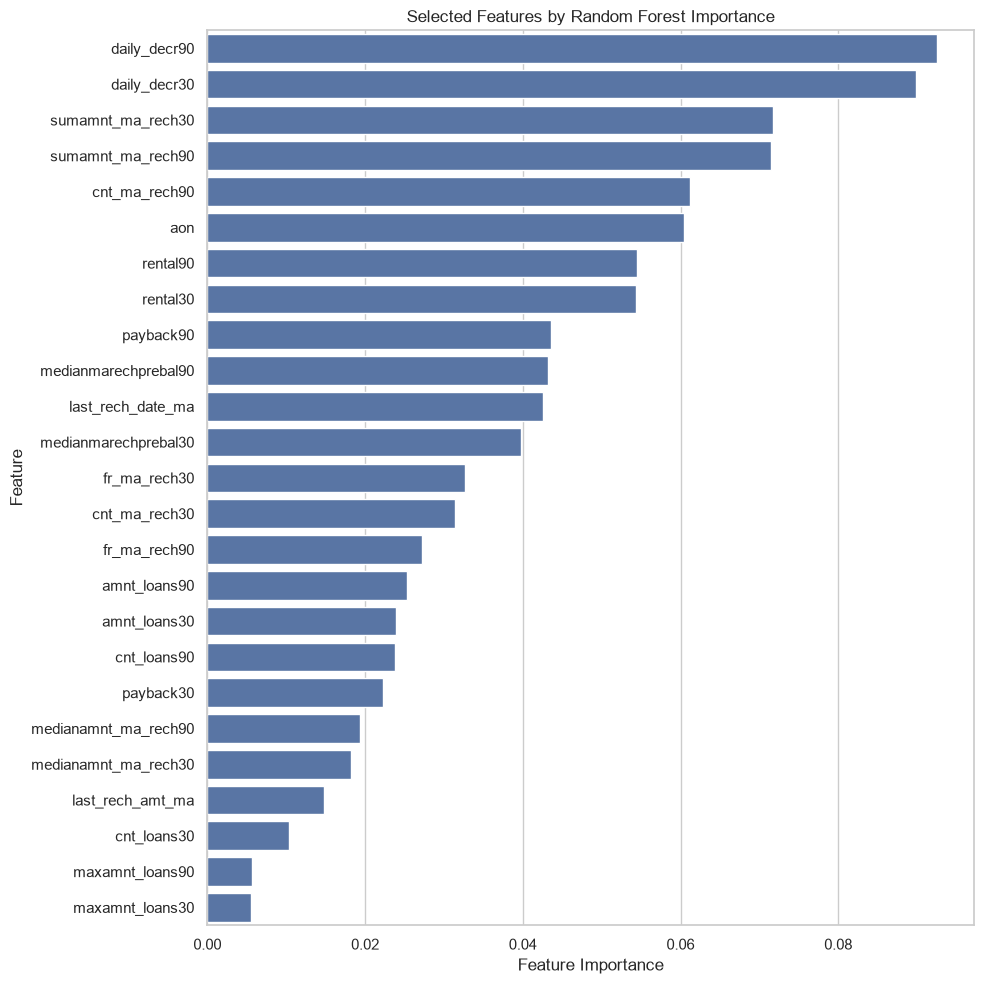

In [49]:
selected_importance = feature_importance[
    feature_importance["Feature"].isin(selected_features)
].copy()

plt.figure(figsize=(10, 10))

sns.barplot(
    data=selected_importance,
    x="Importance",
    y="Feature"
)

plt.title("Selected Features by Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [50]:
import os
import json

os.makedirs("../models", exist_ok=True)

feature_path = "../models/selected_features.json"

with open(feature_path, "w") as f:
    json.dump(selected_features, f, indent=4)

print("Selected feature list saved to:", feature_path)

Selected feature list saved to: ../models/selected_features.json


## 11. Train-Test Split

The selected features are divided into training and testing datasets.

A stratified 80:20 split is used to preserve the original repayment-class distribution in both datasets.

- 80% of the data is used for training.
- 20% of the data is used for testing.
- `random_state=42` ensures reproducibility.
- `stratify=y` maintains the class distribution in both sets.

In [51]:
from sklearn.model_selection import train_test_split

# Split the selected features and target variable
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print(f"Total samples    : {len(X_selected)}")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

TRAIN-TEST SPLIT
Total samples    : 209593
Training samples : 167674
Testing samples  : 41919

Training feature shape: (167674, 25)
Testing feature shape : (41919, 25)

Training target distribution:
label
1    146744
0     20930
Name: count, dtype: int64
label
1    87.52
0    12.48
Name: proportion, dtype: float64

Testing target distribution:
label
1    36687
0     5232
Name: count, dtype: int64
label
1    87.52
0    12.48
Name: proportion, dtype: float64


## 12. Feature Scaling

The selected numerical features are scaled before model training.

Standardization transforms the features so that they have a mean close to 0 and a standard deviation close to 1.

The scaler is fitted only on the training data to prevent data leakage. The same transformation is then applied to the testing data.

- Training data → `fit_transform()`
- Testing data → `transform()`
- Scaling method → `StandardScaler`

In [52]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to testing data
X_test_scaled = scaler.transform(X_test)

print("=" * 70)
print("FEATURE SCALING")
print("=" * 70)

print("Original training shape :", X_train.shape)
print("Scaled training shape   :", X_train_scaled.shape)

print("Original testing shape  :", X_test.shape)
print("Scaled testing shape    :", X_test_scaled.shape)

print("\nTraining scaled mean:")
print(X_train_scaled.mean(axis=0).round(4))

print("\nTraining scaled standard deviation:")
print(X_train_scaled.std(axis=0).round(4))

FEATURE SCALING
Original training shape : (167674, 25)
Scaled training shape   : (167674, 25)
Original testing shape  : (41919, 25)
Scaled testing shape    : (41919, 25)

Training scaled mean:
[-0.  0.  0. -0.  0. -0.  0. -0. -0. -0. -0. -0. -0.  0.  0. -0. -0. -0.
 -0.  0. -0. -0. -0. -0.  0.]

Training scaled standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]


## 13. Baseline Random Forest Model

A baseline Random Forest classifier is trained using the selected features.

Random Forest is chosen as the baseline ensemble model because it can capture nonlinear relationships between customer repayment behavior and the target variable.

Since the target classes are imbalanced, `class_weight="balanced"` is used to give greater importance to the minority repayment class.

Model configuration:

- Algorithm: Random Forest Classifier
- Number of trees: 100
- Class weighting: Balanced
- Random state: 42
- Training data: Scaled training features

In [53]:
from sklearn.ensemble import RandomForestClassifier

# Create baseline Random Forest model
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train the baseline model
baseline_rf.fit(X_train_scaled, y_train)

print("=" * 70)
print("BASELINE RANDOM FOREST MODEL")
print("=" * 70)
print("Model trained successfully.")
print("Number of trees :", baseline_rf.n_estimators)
print("Number of features :", X_train_scaled.shape[1])
print("Class weight :", baseline_rf.class_weight)

BASELINE RANDOM FOREST MODEL
Model trained successfully.
Number of trees : 100
Number of features : 25
Class weight : balanced


## 14. Baseline Random Forest Evaluation

The trained baseline Random Forest model is evaluated on the unseen testing dataset.

The following classification metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

The evaluation focuses on both classes because the repayment target is imbalanced.

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Generate predictions on the test set
y_pred_baseline = baseline_rf.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline, zero_division=0)
recall = recall_score(y_test, y_pred_baseline, zero_division=0)
f1 = f1_score(y_test, y_pred_baseline, zero_division=0)

print("=" * 70)
print("BASELINE RANDOM FOREST — EVALUATION")
print("=" * 70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(y_test, y_pred_baseline)

print(cm)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Class 0", "Class 1"],
    zero_division=0
))

BASELINE RANDOM FOREST — EVALUATION
Accuracy  : 0.9044
Precision : 0.9412
Recall    : 0.9501
F1-Score  : 0.9456

CONFUSION MATRIX
[[ 3056  2176]
 [ 1832 34855]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       0.63      0.58      0.60      5232
     Class 1       0.94      0.95      0.95     36687

    accuracy                           0.90     41919
   macro avg       0.78      0.77      0.77     41919
weighted avg       0.90      0.90      0.90     41919



## 15. Confusion Matrix Visualization

The confusion matrix is visualized as a heatmap to better understand the
classification performance of the baseline Random Forest model.

The matrix shows the number of correctly and incorrectly classified samples
for both repayment classes.

This visualization helps identify whether the model is biased toward the
majority class.

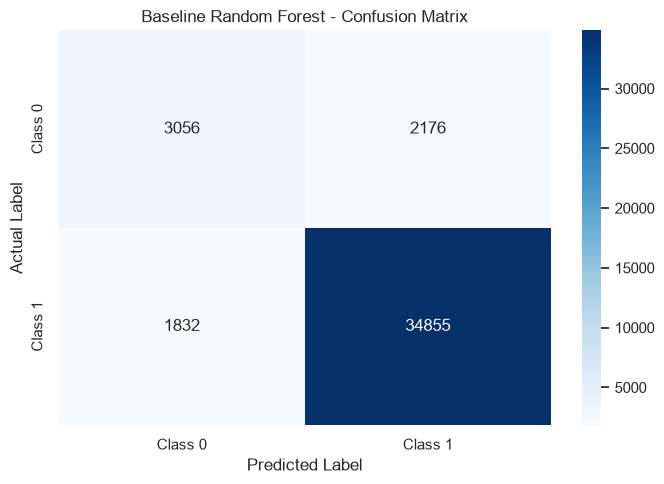

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)

plt.title("Baseline Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

### Baseline Model Observation

The baseline Random Forest achieves high overall accuracy and strong
performance for the majority class.

However, the minority class has lower precision, recall, and F1-score.
Therefore, further model improvement will focus on improving minority-class
recognition while maintaining strong overall predictive performance.

## 16. Baseline Random Forest Feature Importance

Random Forest provides feature importance scores based on the contribution of
each feature to the decision trees.

The importance scores are extracted from the trained baseline model and ranked
from highest to lowest.

This analysis helps identify the most influential features for predicting
loan repayment behavior.

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": baseline_rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("BASELINE RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

print(feature_importance.to_string(index=False))

BASELINE RANDOM FOREST FEATURE IMPORTANCE
             Feature  Importance
        daily_decr90    0.093366
   sumamnt_ma_rech90    0.093240
        daily_decr30    0.088164
   sumamnt_ma_rech30    0.077888
       cnt_ma_rech90    0.076912
                 aon    0.063343
            rental30    0.055640
            rental90    0.055560
   last_rech_date_ma    0.043436
medianmarechprebal90    0.043222
           payback90    0.042774
medianmarechprebal30    0.038691
        amnt_loans90    0.029256
        fr_ma_rech30    0.028329
        fr_ma_rech90    0.028028
        amnt_loans30    0.023934
           payback30    0.020846
medianamnt_ma_rech90    0.018062
medianamnt_ma_rech30    0.017314
       cnt_ma_rech30    0.015207
    last_rech_amt_ma    0.014880
         cnt_loans90    0.012906
         cnt_loans30    0.008371
     maxamnt_loans30    0.005438
     maxamnt_loans90    0.005190


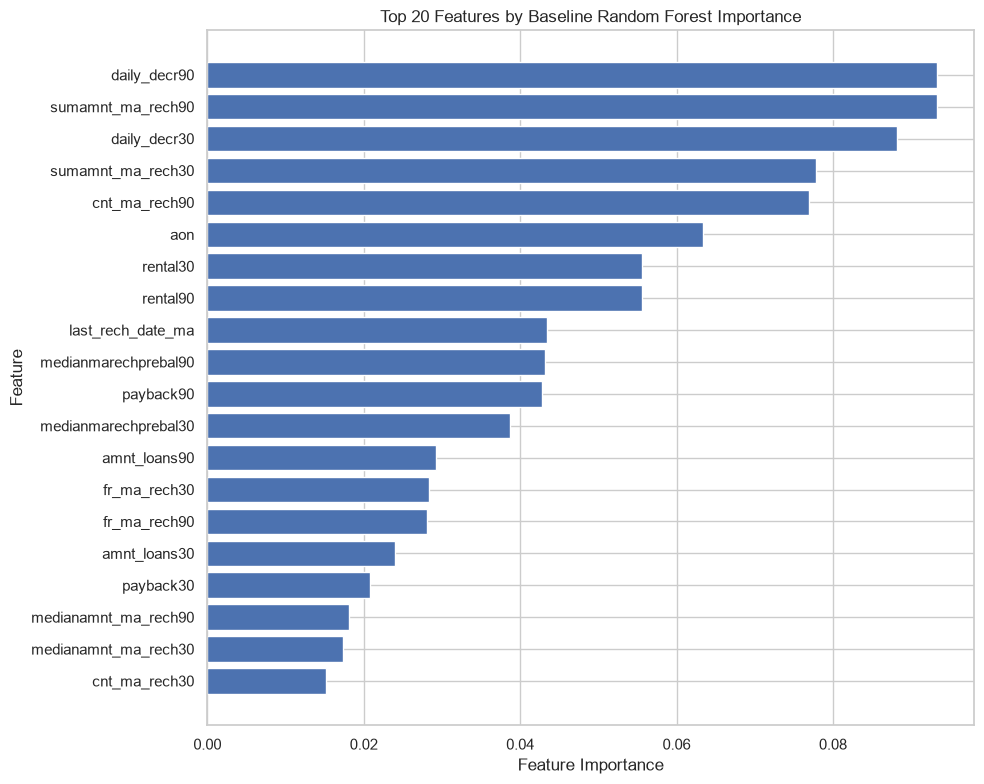

In [57]:
top_20_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20_features["Feature"][::-1],
    top_20_features["Importance"][::-1]
)

plt.title("Top 20 Features by Baseline Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 17. ROC-AUC Evaluation

The baseline Random Forest is further evaluated using predicted probabilities.

ROC-AUC measures the model's ability to distinguish between the two repayment
classes across different classification thresholds.

The ROC curve is also plotted to visually assess the discrimination capability
of the baseline model.

In [58]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Generate probability predictions for Class 1
y_prob_baseline = baseline_rf.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_baseline)

print("=" * 70)
print("BASELINE RANDOM FOREST — ROC-AUC")
print("=" * 70)
print(f"ROC-AUC Score : {roc_auc:.4f}")

BASELINE RANDOM FOREST — ROC-AUC
ROC-AUC Score : 0.8979


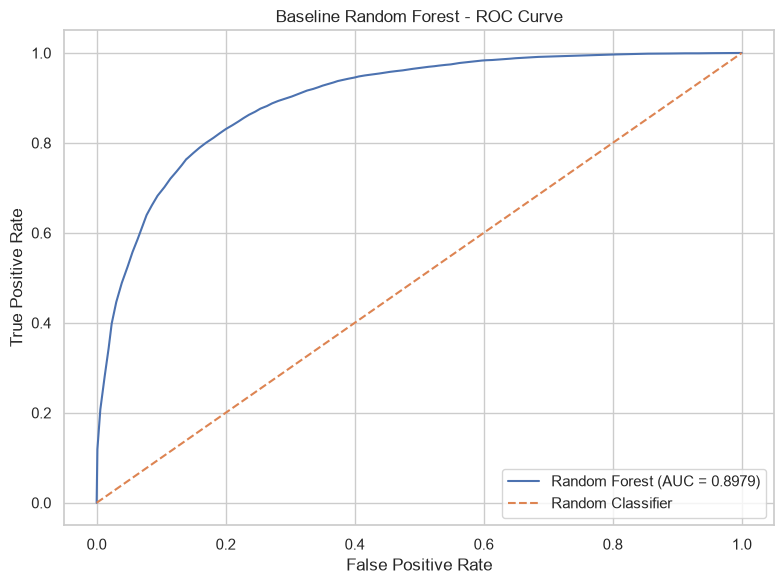

In [59]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_baseline)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Baseline Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 18. Precision-Recall Curve

The Precision-Recall curve is used to evaluate the baseline Random Forest
under the imbalanced target distribution.

Unlike ROC-AUC, the Precision-Recall curve focuses directly on the trade-off
between precision and recall.

Average Precision (AP) is calculated to summarize the Precision-Recall
performance of the model.

In [60]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate Precision-Recall values
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob_baseline
)

# Calculate Average Precision
average_precision = average_precision_score(
    y_test,
    y_prob_baseline
)

print("=" * 70)
print("BASELINE RANDOM FOREST — PRECISION-RECALL")
print("=" * 70)
print(f"Average Precision (AP) : {average_precision:.4f}")

BASELINE RANDOM FOREST — PRECISION-RECALL
Average Precision (AP) : 0.9811


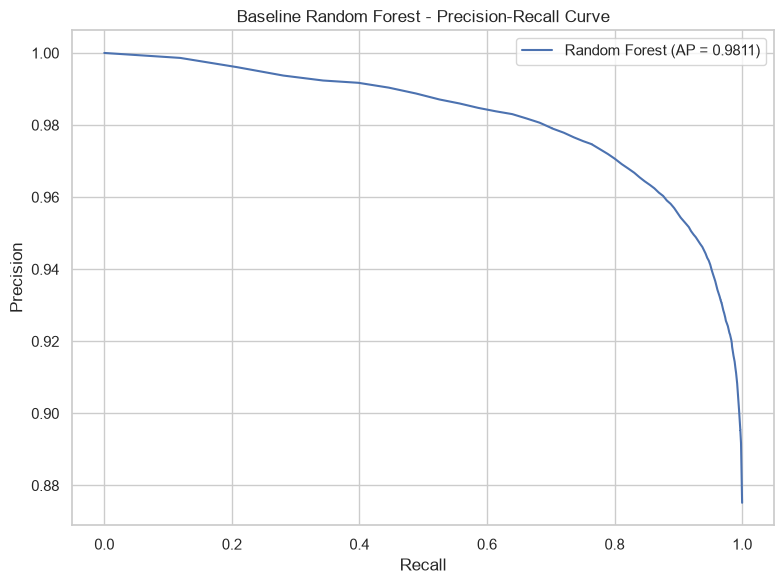

In [61]:
# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Random Forest (AP = {average_precision:.4f})"
)

plt.title("Baseline Random Forest - Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 19. Classification Threshold Analysis

The default classification threshold of 0.50 is examined to determine whether
another threshold can provide a better balance between precision and recall.

The predicted probability of Class 1 is evaluated at multiple thresholds.

For each threshold, accuracy, precision, recall, and F1-score are calculated.

This analysis helps identify an appropriate operating threshold based on the
repayment classification objective rather than relying only on the default
0.50 threshold.

In [62]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Thresholds to evaluate
thresholds_to_test = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds_to_test:

    # Convert probabilities into class predictions
    y_pred_threshold = (y_prob_baseline >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("=" * 70)
print("CLASSIFICATION THRESHOLD ANALYSIS")
print("=" * 70)

print(
    threshold_results_df.round(4).to_string(index=False)
)

CLASSIFICATION THRESHOLD ANALYSIS
 Threshold  Accuracy  Precision  Recall  F1-Score
      0.10    0.9016     0.9030  0.9944    0.9465
      0.15    0.9061     0.9092  0.9917    0.9487
      0.20    0.9083     0.9135  0.9889    0.9497
      0.25    0.9096     0.9177  0.9851    0.9502
      0.30    0.9106     0.9219  0.9810    0.9505
      0.35    0.9092     0.9256  0.9746    0.9495
      0.40    0.9087     0.9305  0.9680    0.9489
      0.45    0.9068     0.9355  0.9597    0.9474
      0.50    0.9044     0.9412  0.9501    0.9456
      0.55    0.8987     0.9462  0.9376    0.9419
      0.60    0.8881     0.9505  0.9200    0.9350
      0.65    0.8746     0.9557  0.8984    0.9261
      0.70    0.8551     0.9612  0.8695    0.9131
      0.75    0.8270     0.9668  0.8309    0.8937
      0.80    0.7866     0.9733  0.7776    0.8645
      0.85    0.7259     0.9791  0.7018    0.8176
      0.90    0.6301     0.9848  0.5864    0.7351


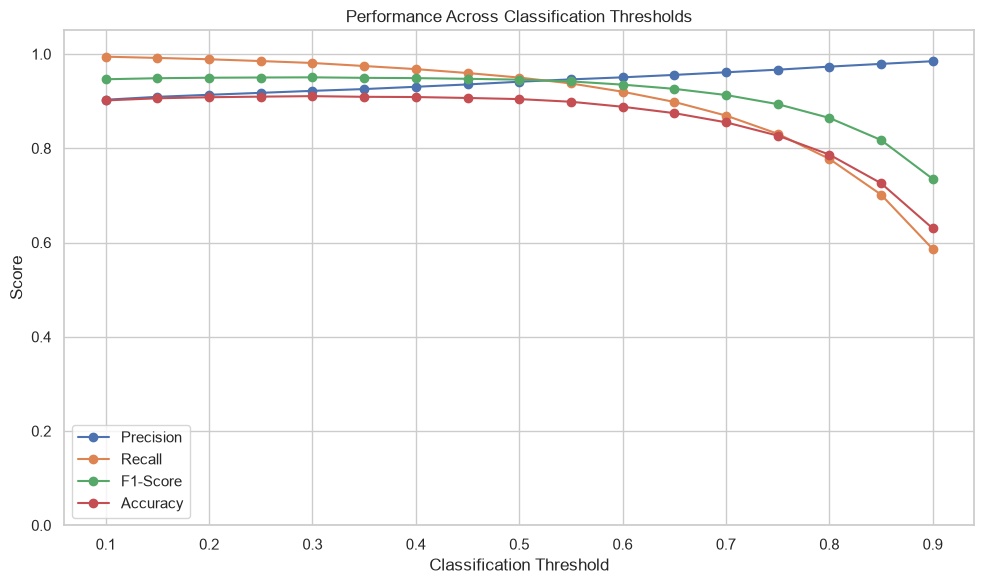

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.title("Performance Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Threshold Analysis Observation

The threshold analysis shows how changing the classification threshold affects
precision, recall, F1-score, and accuracy.

The final threshold should not be selected using accuracy alone because the
dataset contains a substantial class imbalance.

The threshold providing the most appropriate balance between the required
precision and recall will be considered for the final model.

## 20. Evaluation at Selected Classification Threshold

The threshold analysis identified 0.30 as the threshold with the highest
F1-score among the evaluated thresholds.

The model is therefore evaluated at a threshold of 0.30, with particular
attention to the performance of both repayment classes.

The confusion matrix and classification report are used to compare the
threshold-based predictions with the default 0.50 threshold.

In [64]:
# Select threshold based on maximum F1-score
selected_threshold = 0.30

# Generate predictions using the selected threshold
y_pred_threshold_030 = (
    y_prob_baseline >= selected_threshold
).astype(int)

# Calculate confusion matrix
cm_030 = confusion_matrix(
    y_test,
    y_pred_threshold_030
)

print("=" * 70)
print("RANDOM FOREST — THRESHOLD 0.30")
print("=" * 70)

print(f"Selected threshold : {selected_threshold}")

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred_threshold_030):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_threshold_030, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_threshold_030, zero_division=0):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_threshold_030, zero_division=0):.4f}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX — THRESHOLD 0.30")
print("=" * 70)

print(cm_030)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — THRESHOLD 0.30")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_threshold_030,
        target_names=["Class 0", "Class 1"],
        zero_division=0
    )
)

RANDOM FOREST — THRESHOLD 0.30
Selected threshold : 0.3

Accuracy  : 0.9107
Precision : 0.9211
Recall    : 0.9821
F1-Score  : 0.9506

CONFUSION MATRIX — THRESHOLD 0.30
[[ 2144  3088]
 [  655 36032]]

CLASSIFICATION REPORT — THRESHOLD 0.30
              precision    recall  f1-score   support

     Class 0       0.77      0.41      0.53      5232
     Class 1       0.92      0.98      0.95     36687

    accuracy                           0.91     41919
   macro avg       0.84      0.70      0.74     41919
weighted avg       0.90      0.91      0.90     41919



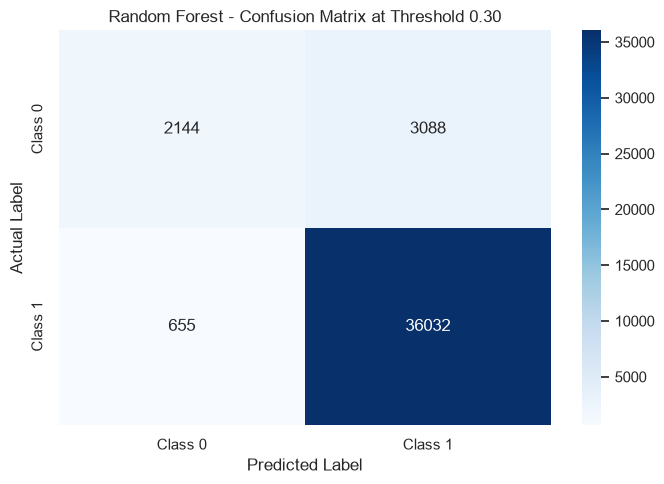

In [65]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_030,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)

plt.title("Random Forest - Confusion Matrix at Threshold 0.30")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

## 21. Class-Balanced Random Forest

The baseline model uses `class_weight="balanced"` to compensate for the
imbalanced repayment classes.

A second Random Forest configuration is trained using a stronger weighting
strategy for the minority class.

The purpose is to determine whether increasing the importance of Class 0 can
improve its recall and F1-score without causing an unacceptable reduction in
overall performance.

The comparison will use:

- Accuracy
- Precision
- Recall
- F1-score
- Macro F1-score
- Classification Report
- Confusion Matrix

In [66]:
# Stronger minority-class weighting
balanced_rf_strong = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight={0: 3, 1: 1}
)

# Train the model
balanced_rf_strong.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_strong = balanced_rf_strong.predict(X_test_scaled)

print("=" * 70)
print("STRONGLY CLASS-WEIGHTED RANDOM FOREST")
print("=" * 70)

print("Model trained successfully.")
print("Class weights :", balanced_rf_strong.class_weight)

STRONGLY CLASS-WEIGHTED RANDOM FOREST
Model trained successfully.
Class weights : {0: 3, 1: 1}


In [67]:
# Evaluate strongly class-weighted model

strong_accuracy = accuracy_score(y_test, y_pred_strong)
strong_precision = precision_score(
    y_test,
    y_pred_strong,
    zero_division=0
)
strong_recall = recall_score(
    y_test,
    y_pred_strong,
    zero_division=0
)
strong_f1 = f1_score(
    y_test,
    y_pred_strong,
    zero_division=0
)

print("=" * 70)
print("STRONGLY CLASS-WEIGHTED RANDOM FOREST — EVALUATION")
print("=" * 70)

print(f"Accuracy  : {strong_accuracy:.4f}")
print(f"Precision : {strong_precision:.4f}")
print(f"Recall    : {strong_recall:.4f}")
print(f"F1-Score  : {strong_f1:.4f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_strong,
        target_names=["Class 0", "Class 1"],
        zero_division=0
    )
)

STRONGLY CLASS-WEIGHTED RANDOM FOREST — EVALUATION
Accuracy  : 0.9090
Precision : 0.9344
Recall    : 0.9637
F1-Score  : 0.9488

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       0.67      0.53      0.59      5232
     Class 1       0.93      0.96      0.95     36687

    accuracy                           0.91     41919
   macro avg       0.80      0.74      0.77     41919
weighted avg       0.90      0.91      0.90     41919



CONFUSION MATRIX
[[ 2750  2482]
 [ 1332 35355]]


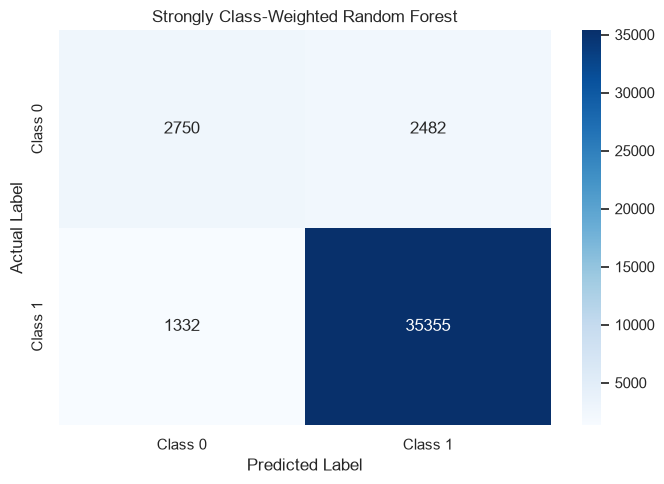

In [68]:
# Confusion matrix
cm_strong = confusion_matrix(
    y_test,
    y_pred_strong
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm_strong)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_strong,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)

plt.title("Strongly Class-Weighted Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

## 22. Random Forest Class-Weight Comparison

Different class-weight configurations are evaluated to determine whether
the minority Class 0 performance can be improved while maintaining strong
overall repayment prediction performance.

The following configurations are compared:

- Balanced: {0: 1, 1: 1}
- Moderate: {0: 2, 1: 1}
- Strong: {0: 3, 1: 1}
- Very Strong: {0: 4, 1: 1}

The models are compared using:

- Accuracy
- Class 0 Precision
- Class 0 Recall
- Class 0 F1-score
- Class 1 F1-score
- Macro F1-score

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score
)
import pandas as pd

# Different class-weight configurations
weight_configs = {
    "1:1": {0: 1, 1: 1},
    "2:1": {0: 2, 1: 1},
    "3:1": {0: 3, 1: 1},
    "4:1": {0: 4, 1: 1}
}

results = []

for name, weights in weight_configs.items():

    print(f"Training Random Forest with class weight {name}...")

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight=weights
    )

    rf.fit(X_train_scaled, y_train)

    predictions = rf.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, predictions)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        predictions,
        labels=[0, 1],
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    results.append({
        "Class Weight": name,
        "Accuracy": accuracy,
        "Class 0 Precision": precision[0],
        "Class 0 Recall": recall[0],
        "Class 0 F1": f1[0],
        "Class 1 Precision": precision[1],
        "Class 1 Recall": recall[1],
        "Class 1 F1": f1[1],
        "Macro F1": macro_f1
    })

weight_results = pd.DataFrame(results)

print("\n" + "=" * 100)
print("CLASS-WEIGHT COMPARISON")
print("=" * 100)

print(
    weight_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Training Random Forest with class weight 1:1...
Training Random Forest with class weight 2:1...
Training Random Forest with class weight 3:1...
Training Random Forest with class weight 4:1...

CLASS-WEIGHT COMPARISON
Class Weight  Accuracy  Class 0 Precision  Class 0 Recall  Class 0 F1  Class 1 Precision  Class 1 Recall  Class 1 F1  Macro F1
         1:1    0.9117             0.7526          0.4354      0.5516             0.9240          0.9796      0.9510    0.7513
         2:1    0.9096             0.6941          0.4935      0.5769             0.9306          0.9690      0.9494    0.7631
         3:1    0.9090             0.6737          0.5256      0.5905             0.9344          0.9637      0.9488    0.7697
         4:1    0.9076             0.6557          0.5461      0.5959             0.9368          0.9591      0.9478    0.7719


## 22.1 Selecting the Best Class Weight

The best class-weight configuration is selected based on the balance between
Class 0 performance, Class 1 performance, accuracy, and macro F1-score.

Because the dataset is imbalanced, Class 0 recall and F1-score are given
particular importance rather than selecting the model using accuracy alone.

## 23. Random Forest Hyperparameter Tuning

The class-weight comparison identified `{0: 4, 1: 1}` as the best
configuration based on Macro F1-score and minority-class performance.

Hyperparameter tuning is now performed to determine whether the Random Forest
performance can be further improved.

The following hyperparameters are evaluated:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required for splitting (`min_samples_split`)
- Minimum samples required at a leaf (`min_samples_leaf`)
- Maximum number of features considered at each split (`max_features`)

The primary evaluation metric is Macro F1-score because the dataset contains
a significant class imbalance.

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Random Forest with selected class weight
rf_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight={0: 4, 1: 1}
)

# Hyperparameter search space
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("=" * 70)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)

random_search.fit(X_train_scaled, y_train)

print("\nBest parameters:")
print(random_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(f"{random_search.best_score_:.4f}")

RANDOM FOREST HYPERPARAMETER TUNING
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 25}

Best cross-validation Macro F1:
0.7767


## 23.1 Tuned Random Forest Evaluation

The best Random Forest configuration identified through randomized
hyperparameter search is evaluated on the unseen test set.

Performance is measured using accuracy, precision, recall, F1-score,
Macro F1-score, and the confusion matrix.

In [71]:
# Best tuned model
best_rf = random_search.best_estimator_

# Predictions
y_pred_tuned = best_rf.predict(X_test_scaled)

# Metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
macro_f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 70)
print("TUNED RANDOM FOREST — EVALUATION")
print("=" * 70)

print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Macro F1  : {macro_f1_tuned:.4f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_tuned,
        digits=4,
        zero_division=0
    )
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(cm_tuned)


TUNED RANDOM FOREST — EVALUATION
Accuracy  : 0.9034
Macro F1  : 0.7782

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.6140    0.6089    0.6115      5232
           1     0.9443    0.9454    0.9448     36687

    accuracy                         0.9034     41919
   macro avg     0.7791    0.7772    0.7782     41919
weighted avg     0.9031    0.9034    0.9032     41919


CONFUSION MATRIX
[[ 3186  2046]
 [ 2003 34684]]


## 24. Tuned Random Forest — Detailed Evaluation

The optimized Random Forest model is evaluated using additional
classification metrics and visualizations.

The evaluation includes:

- Confusion Matrix
- ROC Curve and ROC-AUC
- Precision-Recall Curve
- Average Precision
- Classification Threshold Analysis

These evaluations help determine whether the tuned model provides
better discrimination and minority-class performance than the
baseline Random Forest model.

## 24.1 Tuned Random Forest — Confusion Matrix

The confusion matrix is used to examine the classification performance
of the tuned Random Forest model for both repayment classes.

It shows the number of correctly and incorrectly classified samples
for Class 0 and Class 1.

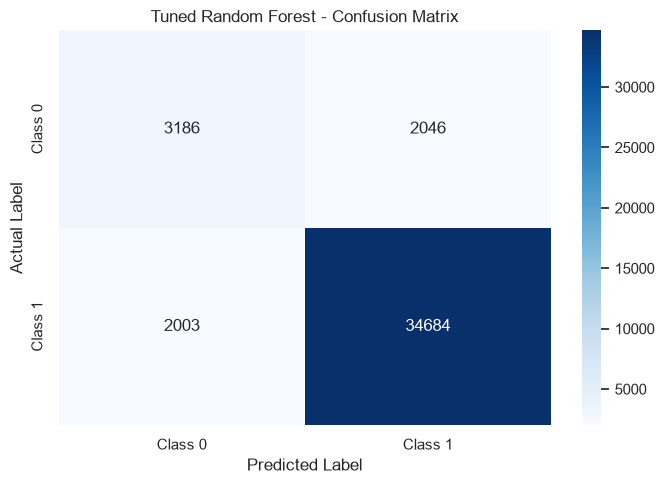

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.show()

## 25. ROC Curve and ROC-AUC

The Receiver Operating Characteristic (ROC) curve evaluates the ability
of the tuned Random Forest to distinguish between the two repayment classes
across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the overall
discriminative ability of the model.

TUNED RANDOM FOREST — ROC-AUC
ROC-AUC Score : 0.9024


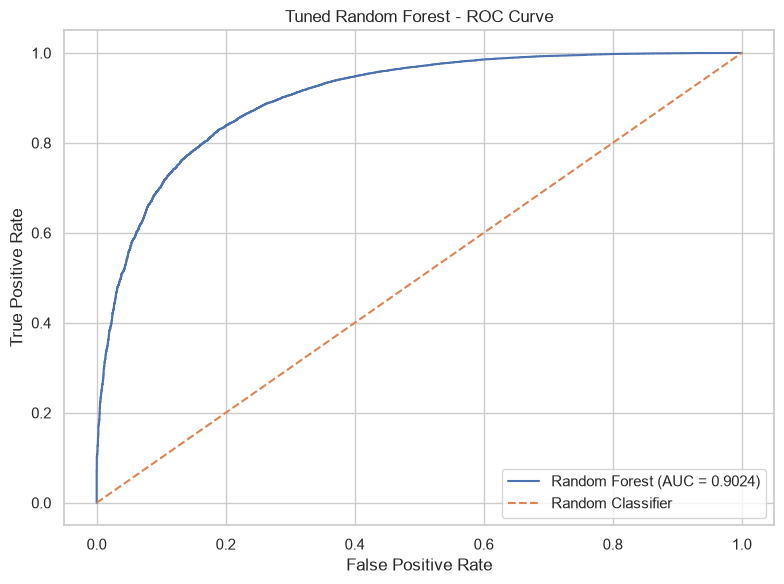

In [73]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities for Class 1
y_prob_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]

# ROC curve
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(
    y_test,
    y_prob_tuned
)

# ROC-AUC
roc_auc_tuned = roc_auc_score(
    y_test,
    y_prob_tuned
)

print("=" * 70)
print("TUNED RANDOM FOREST — ROC-AUC")
print("=" * 70)

print(f"ROC-AUC Score : {roc_auc_tuned:.4f}")

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f"Random Forest (AUC = {roc_auc_tuned:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Random Forest - ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## 26. Precision-Recall Curve

The Precision-Recall curve evaluates the relationship between precision
and recall across different classification thresholds.

This analysis is particularly useful for the repayment prediction problem
because the target classes are imbalanced.

Average Precision (AP) is also calculated to summarize the
Precision-Recall performance.

TUNED RANDOM FOREST — PRECISION-RECALL
Average Precision (AP) : 0.9828


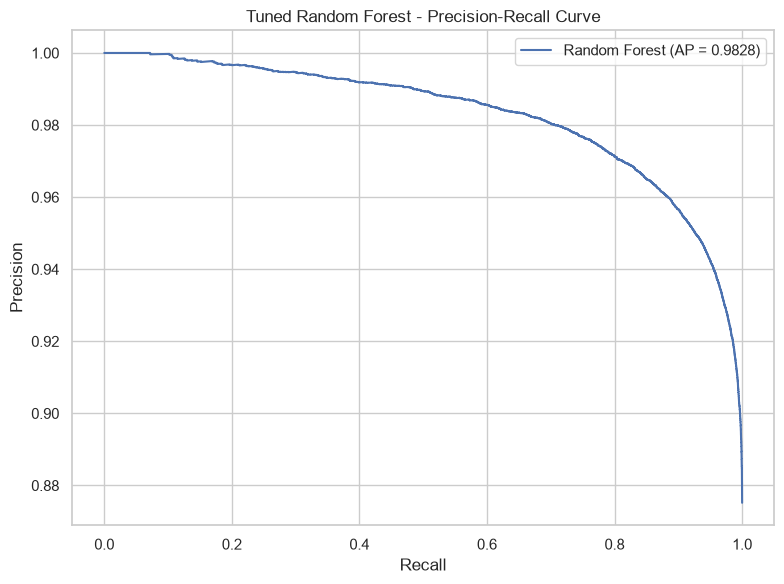

In [74]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall values
precision_tuned, recall_tuned, pr_thresholds_tuned = precision_recall_curve(
    y_test,
    y_prob_tuned
)

# Average Precision
ap_tuned = average_precision_score(
    y_test,
    y_prob_tuned
)

print("=" * 70)
print("TUNED RANDOM FOREST — PRECISION-RECALL")
print("=" * 70)

print(f"Average Precision (AP) : {ap_tuned:.4f}")

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall_tuned,
    precision_tuned,
    label=f"Random Forest (AP = {ap_tuned:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Tuned Random Forest - Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## 27. Threshold Analysis for Tuned Random Forest

The default classification threshold of 0.50 is not necessarily optimal
for an imbalanced classification problem.

Different probability thresholds are evaluated to determine whether
the tuned Random Forest can achieve better accuracy, precision, recall,
and F1-score.

The threshold producing the highest F1-score is identified for further
evaluation.

In [75]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds_to_test = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("=" * 70)
print("TUNED RANDOM FOREST — CLASSIFICATION THRESHOLD ANALYSIS")
print("=" * 70)

print(
    threshold_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1-Score": "{:.4f}".format
        }
    )
)

TUNED RANDOM FOREST — CLASSIFICATION THRESHOLD ANALYSIS
 Threshold Accuracy Precision Recall F1-Score
      0.10   0.9038    0.9048 0.9947   0.9476
      0.15   0.9081    0.9107 0.9924   0.9498
      0.20   0.9107    0.9160 0.9885   0.9509
      0.25   0.9125    0.9212 0.9843   0.9517
      0.30   0.9128    0.9251 0.9796   0.9516
      0.35   0.9121    0.9297 0.9732   0.9510
      0.40   0.9108    0.9346 0.9656   0.9499
      0.45   0.9078    0.9397 0.9561   0.9478
      0.50   0.9034    0.9443 0.9454   0.9448
      0.55   0.8959    0.9490 0.9310   0.9399
      0.60   0.8854    0.9532 0.9139   0.9331
      0.65   0.8700    0.9590 0.8896   0.9230
      0.70   0.8465    0.9644 0.8562   0.9071
      0.75   0.8154    0.9698 0.8145   0.8854
      0.80   0.7714    0.9761 0.7574   0.8529
      0.85   0.7077    0.9820 0.6785   0.8025
      0.90   0.6120    0.9872 0.5640   0.7179


## 28. Optimal Classification Threshold

The threshold with the highest F1-score is selected as the optimal
classification threshold.

This threshold provides a balance between precision and recall for
the positive repayment class.

In [76]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("=" * 70)
print("OPTIMAL CLASSIFICATION THRESHOLD")
print("=" * 70)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Accuracy       : {best_threshold_row['Accuracy']:.4f}")
print(f"Precision      : {best_threshold_row['Precision']:.4f}")
print(f"Recall         : {best_threshold_row['Recall']:.4f}")
print(f"F1-Score       : {best_threshold_row['F1-Score']:.4f}")

OPTIMAL CLASSIFICATION THRESHOLD
Best Threshold : 0.25
Accuracy       : 0.9125
Precision      : 0.9212
Recall         : 0.9843
F1-Score       : 0.9517


## 29. Performance Across Classification Thresholds

The effect of changing the classification threshold is visualized
using Accuracy, Precision, Recall, and F1-Score.

This helps identify the threshold that provides the most suitable
balance between the evaluation metrics.

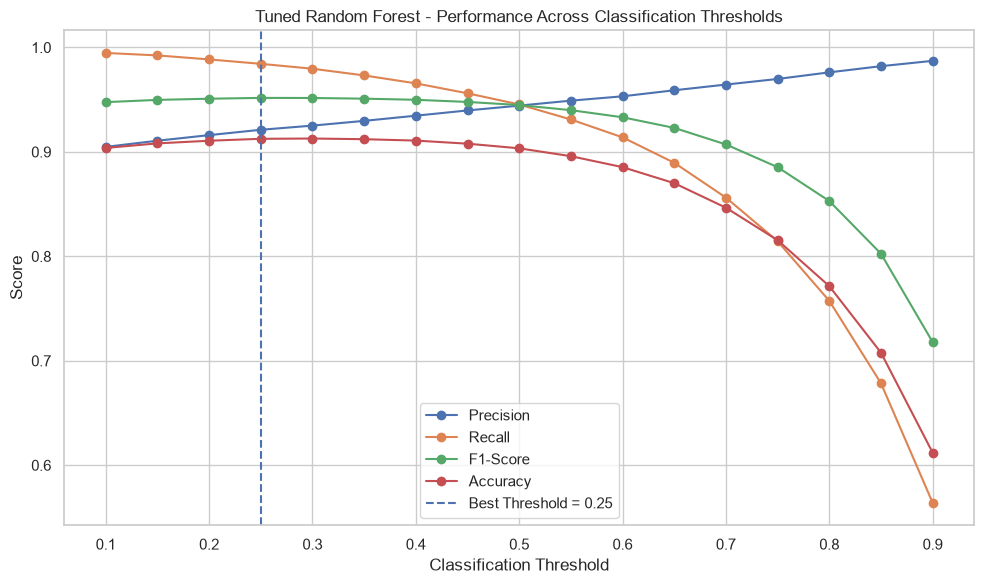

In [77]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Tuned Random Forest - Performance Across Classification Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## 30. Tuned Random Forest — Optimal Threshold Evaluation

The threshold analysis identified 0.25 as the optimal classification
threshold based on the highest F1-score.

The tuned Random Forest is therefore evaluated using a classification
threshold of 0.25 instead of the default threshold of 0.50.

The resulting performance is evaluated using accuracy, precision,
recall, F1-score, classification report, and confusion matrix.

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Optimal threshold identified from threshold analysis
optimal_threshold = 0.25

# Convert probabilities into predictions
y_pred_optimal = (
    y_prob_tuned >= optimal_threshold
).astype(int)

# Calculate metrics
optimal_accuracy = accuracy_score(
    y_test,
    y_pred_optimal
)

optimal_precision = precision_score(
    y_test,
    y_pred_optimal,
    zero_division=0
)

optimal_recall = recall_score(
    y_test,
    y_pred_optimal,
    zero_division=0
)

optimal_f1 = f1_score(
    y_test,
    y_pred_optimal,
    zero_division=0
)

optimal_cm = confusion_matrix(
    y_test,
    y_pred_optimal
)

print("=" * 70)
print("TUNED RANDOM FOREST — OPTIMAL THRESHOLD")
print("=" * 70)

print(f"Selected threshold : {optimal_threshold:.2f}")
print(f"Accuracy            : {optimal_accuracy:.4f}")
print(f"Precision           : {optimal_precision:.4f}")
print(f"Recall              : {optimal_recall:.4f}")
print(f"F1-Score            : {optimal_f1:.4f}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(optimal_cm)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_optimal,
        digits=4,
        zero_division=0
    )
)

TUNED RANDOM FOREST — OPTIMAL THRESHOLD
Selected threshold : 0.25
Accuracy            : 0.9125
Precision           : 0.9212
Recall              : 0.9843
F1-Score            : 0.9517

CONFUSION MATRIX
[[ 2141  3091]
 [  576 36111]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.7880    0.4092    0.5387      5232
           1     0.9212    0.9843    0.9517     36687

    accuracy                         0.9125     41919
   macro avg     0.8546    0.6968    0.7452     41919
weighted avg     0.9045    0.9125    0.9001     41919



## 31. Confusion Matrix at Optimal Threshold

The confusion matrix at the selected threshold of 0.25 is visualized
to examine the classification performance of both repayment classes.

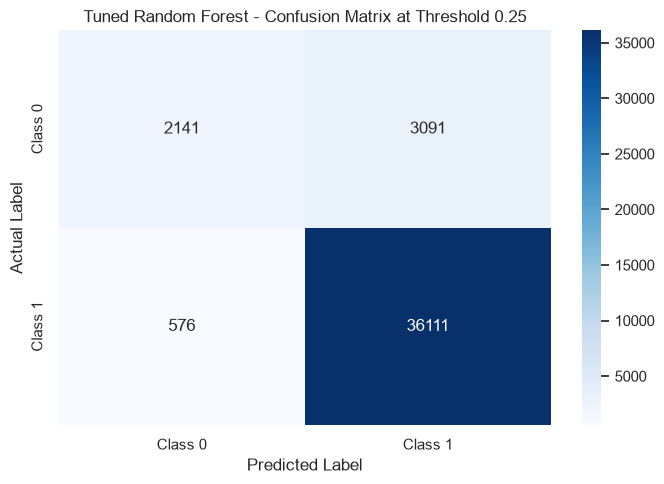

In [79]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    optimal_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"]
)

plt.title("Tuned Random Forest - Confusion Matrix at Threshold 0.25")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.show()

## 32. Random Forest Model Comparison

Different Random Forest configurations are compared to identify the
most suitable final model.

The comparison considers accuracy, minority-class performance,
F1-score, and Macro F1-score.

Because the dataset is imbalanced, Macro F1 and minority-class
performance are considered alongside overall accuracy.

In [80]:
comparison_data = [
    {
        "Model": "Baseline RF",
        "Accuracy": 0.9044,
        "Macro F1": 0.77,
        "Class 0 F1": 0.60,
        "Class 0 Recall": 0.58
    },
    {
        "Model": "Class Weight 1:1",
        "Accuracy": 0.9117,
        "Macro F1": 0.7513,
        "Class 0 F1": 0.5516,
        "Class 0 Recall": 0.4354
    },
    {
        "Model": "Class Weight 2:1",
        "Accuracy": 0.9096,
        "Macro F1": 0.7631,
        "Class 0 F1": 0.5769,
        "Class 0 Recall": 0.4935
    },
    {
        "Model": "Class Weight 3:1",
        "Accuracy": 0.9090,
        "Macro F1": 0.7697,
        "Class 0 F1": 0.5905,
        "Class 0 Recall": 0.5256
    },
    {
        "Model": "Class Weight 4:1",
        "Accuracy": 0.9076,
        "Macro F1": 0.7719,
        "Class 0 F1": 0.5959,
        "Class 0 Recall": 0.5461
    },
    {
        "Model": "Tuned RF (0.50)",
        "Accuracy": 0.9034,
        "Macro F1": 0.7782,
        "Class 0 F1": 0.6115,
        "Class 0 Recall": 0.6089
    },
    {
        "Model": "Tuned RF (0.25)",
        "Accuracy": optimal_accuracy,
        "Macro F1": f1_score(
            y_test,
            y_pred_optimal,
            average="macro",
            zero_division=0
        ),
        "Class 0 F1": classification_report(
            y_test,
            y_pred_optimal,
            output_dict=True,
            zero_division=0
        )["0"]["f1-score"],
        "Class 0 Recall": classification_report(
            y_test,
            y_pred_optimal,
            output_dict=True,
            zero_division=0
        )["0"]["recall"]
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("=" * 90)
print("RANDOM FOREST MODEL COMPARISON")
print("=" * 90)

print(
    comparison_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Macro F1": "{:.4f}".format,
            "Class 0 F1": "{:.4f}".format,
            "Class 0 Recall": "{:.4f}".format
        }
    )
)

RANDOM FOREST MODEL COMPARISON
           Model Accuracy Macro F1 Class 0 F1 Class 0 Recall
     Baseline RF   0.9044   0.7700     0.6000         0.5800
Class Weight 1:1   0.9117   0.7513     0.5516         0.4354
Class Weight 2:1   0.9096   0.7631     0.5769         0.4935
Class Weight 3:1   0.9090   0.7697     0.5905         0.5256
Class Weight 4:1   0.9076   0.7719     0.5959         0.5461
 Tuned RF (0.50)   0.9034   0.7782     0.6115         0.6089
 Tuned RF (0.25)   0.9125   0.7452     0.5387         0.4092


## 33. Threshold Optimization Using Macro F1

The previous threshold analysis selected 0.25 based on the highest
F1-score for Class 1.

However, because the dataset is highly imbalanced, optimizing only
the positive-class F1-score can reduce the performance of the minority
Class 0.

Therefore, Macro F1-score is used to identify a more balanced
classification threshold.

Macro F1 gives equal importance to Class 0 and Class 1 by calculating
the average F1-score across both classes.

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

threshold_results_macro = []

for threshold in np.arange(0.10, 0.91, 0.05):

    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        y_pred_threshold,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred_threshold
    )

    threshold_results_macro.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

threshold_macro_df = pd.DataFrame(
    threshold_results_macro
)

print("=" * 90)
print("THRESHOLD OPTIMIZATION USING MACRO F1")
print("=" * 90)

print(
    threshold_macro_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1-Score": "{:.4f}".format,
            "Macro F1": "{:.4f}".format,
            "Balanced Accuracy": "{:.4f}".format
        }
    )
)

THRESHOLD OPTIMIZATION USING MACRO F1
 Threshold Accuracy Precision Recall F1-Score Macro F1 Balanced Accuracy
      0.10   0.9038    0.9048 0.9947   0.9476   0.6780            0.6304
      0.15   0.9081    0.9107 0.9924   0.9498   0.7064            0.6549
      0.20   0.9107    0.9160 0.9885   0.9509   0.7278            0.6766
      0.25   0.9125    0.9212 0.9843   0.9517   0.7452            0.6968
      0.30   0.9128    0.9251 0.9796   0.9516   0.7557            0.7119
      0.35   0.9121    0.9297 0.9732   0.9510   0.7649            0.7286
      0.40   0.9108    0.9346 0.9656   0.9499   0.7728            0.7461
      0.45   0.9078    0.9397 0.9561   0.9478   0.7773            0.7628
      0.50   0.9034    0.9443 0.9454   0.9448   0.7782            0.7772
      0.55   0.8959    0.9490 0.9310   0.9399   0.7744            0.7902
      0.60   0.8854    0.9532 0.9139   0.9331   0.7660            0.7996
      0.65   0.8700    0.9590 0.8896   0.9230   0.7539            0.8114
      0.70   

## 34. Optimal Threshold Based on Macro F1

The classification threshold with the highest Macro F1-score is selected
as the optimal threshold.

This threshold provides a more balanced evaluation of Class 0 and Class 1
performance than optimizing the F1-score of Class 1 alone.

In [82]:
best_macro_row = threshold_macro_df.loc[
    threshold_macro_df["Macro F1"].idxmax()
]

best_macro_threshold = best_macro_row["Threshold"]

print("=" * 70)
print("OPTIMAL THRESHOLD — MACRO F1")
print("=" * 70)

print(f"Best Threshold     : {best_macro_threshold:.2f}")
print(f"Accuracy           : {best_macro_row['Accuracy']:.4f}")
print(f"Precision          : {best_macro_row['Precision']:.4f}")
print(f"Recall             : {best_macro_row['Recall']:.4f}")
print(f"F1-Score           : {best_macro_row['F1-Score']:.4f}")
print(f"Macro F1           : {best_macro_row['Macro F1']:.4f}")
print(f"Balanced Accuracy  : {best_macro_row['Balanced Accuracy']:.4f}")

OPTIMAL THRESHOLD — MACRO F1
Best Threshold     : 0.50
Accuracy           : 0.9034
Precision          : 0.9443
Recall             : 0.9454
F1-Score           : 0.9448
Macro F1           : 0.7782
Balanced Accuracy  : 0.7772


## 35. Final Threshold Evaluation

The Random Forest is evaluated using the threshold selected according
to the highest Macro F1-score.

The final evaluation includes the classification report and confusion
matrix for both repayment classes.

In [83]:
# Predictions using Macro-F1 optimal threshold
y_pred_macro_optimal = (
    y_prob_tuned >= best_macro_threshold
).astype(int)

# Metrics
final_accuracy = accuracy_score(
    y_test,
    y_pred_macro_optimal
)

final_macro_f1 = f1_score(
    y_test,
    y_pred_macro_optimal,
    average="macro",
    zero_division=0
)

final_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_macro_optimal
)

final_cm = confusion_matrix(
    y_test,
    y_pred_macro_optimal
)

print("=" * 70)
print("FINAL TUNED RANDOM FOREST — THRESHOLD EVALUATION")
print("=" * 70)

print(f"Selected threshold : {best_macro_threshold:.2f}")
print(f"Accuracy            : {final_accuracy:.4f}")
print(f"Macro F1            : {final_macro_f1:.4f}")
print(f"Balanced Accuracy   : {final_balanced_accuracy:.4f}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(final_cm)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_macro_optimal,
        digits=4,
        zero_division=0
    )
)

FINAL TUNED RANDOM FOREST — THRESHOLD EVALUATION
Selected threshold : 0.50
Accuracy            : 0.9034
Macro F1            : 0.7782
Balanced Accuracy   : 0.7772

CONFUSION MATRIX
[[ 3186  2046]
 [ 2003 34684]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.6140    0.6089    0.6115      5232
           1     0.9443    0.9454    0.9448     36687

    accuracy                         0.9034     41919
   macro avg     0.7791    0.7772    0.7782     41919
weighted avg     0.9031    0.9034    0.9032     41919



## 36. Final Tuned Random Forest

The final Random Forest is trained using the optimal hyperparameters
identified during hyperparameter tuning.

Class balancing is retained because the repayment dataset is highly
imbalanced, with Class 1 representing the majority of observations.

The final model uses:

- 300 trees
- Maximum depth of 25
- Minimum samples split of 10
- Minimum samples leaf of 1
- Square-root feature selection
- Balanced class weights

In [87]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# FINAL TUNED RANDOM FOREST
# ============================================================

final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("=" * 70)
print("TRAINING FINAL TUNED RANDOM FOREST")
print("=" * 70)

final_model.fit(
    X_train_scaled,
    y_train
)

print("Model trained successfully.")
print(f"Number of trees    : {final_model.n_estimators}")
print(f"Maximum depth      : {final_model.max_depth}")
print(f"Min samples split  : {final_model.min_samples_split}")
print(f"Min samples leaf   : {final_model.min_samples_leaf}")
print(f"Max features       : {final_model.max_features}")
print(f"Class weight       : {final_model.class_weight}")
print(f"Number of features : {X_train_scaled.shape[1]}")

TRAINING FINAL TUNED RANDOM FOREST
Model trained successfully.
Number of trees    : 300
Maximum depth      : 25
Min samples split  : 10
Min samples leaf   : 1
Max features       : sqrt
Class weight       : balanced
Number of features : 25


## 37. Final Tuned Random Forest — Verification

The final tuned Random Forest is evaluated on the unseen test dataset
using the selected classification threshold of 0.50.

Accuracy, precision, recall, F1-score, Macro F1, balanced accuracy,
confusion matrix, and classification report are calculated.

In [88]:
final_threshold = 0.50

final_probabilities = final_model.predict_proba(
    X_test_scaled
)[:, 1]

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_macro_f1 = f1_score(
    y_test,
    final_predictions,
    average="macro",
    zero_division=0
)

final_balanced_accuracy = balanced_accuracy_score(
    y_test,
    final_predictions
)

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("=" * 70)
print("FINAL TUNED RANDOM FOREST — THRESHOLD 0.50")
print("=" * 70)

print(f"Threshold          : {final_threshold:.2f}")
print(f"Accuracy           : {final_accuracy:.4f}")
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")
print(f"F1-Score           : {final_f1:.4f}")
print(f"Macro F1           : {final_macro_f1:.4f}")
print(f"Balanced Accuracy  : {final_balanced_accuracy:.4f}")

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(final_cm)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)

FINAL TUNED RANDOM FOREST — THRESHOLD 0.50
Threshold          : 0.50
Accuracy           : 0.8890
Precision          : 0.9511
Recall             : 0.9205
F1-Score           : 0.9356
Macro F1           : 0.7681
Balanced Accuracy  : 0.7944

CONFUSION MATRIX
[[ 3497  1735]
 [ 2917 33770]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.55      0.67      0.60      5232
           1       0.95      0.92      0.94     36687

    accuracy                           0.89     41919
   macro avg       0.75      0.79      0.77     41919
weighted avg       0.90      0.89      0.89     41919



## 38. Final Tuned Random Forest — Feature Importance

Feature importance is extracted from the final tuned Random Forest
to identify the input variables that contribute most to repayment
prediction.

The importance values are ranked in descending order and visualized
for interpretation.

FINAL TUNED RANDOM FOREST — FEATURE IMPORTANCE
             Feature  Importance
       cnt_ma_rech90    0.102671
        daily_decr90    0.091909
   sumamnt_ma_rech90    0.086689
        daily_decr30    0.086004
   sumamnt_ma_rech30    0.080428
           payback90    0.047713
                 aon    0.047296
            rental90    0.046944
            rental30    0.046872
   last_rech_date_ma    0.041521
       cnt_ma_rech30    0.040576
medianmarechprebal90    0.037544
medianmarechprebal30    0.035521
        fr_ma_rech90    0.028842
        amnt_loans90    0.027988
        fr_ma_rech30    0.022954
        amnt_loans30    0.022837
           payback30    0.021616
medianamnt_ma_rech90    0.017083
         cnt_loans90    0.017083
medianamnt_ma_rech30    0.015639
    last_rech_amt_ma    0.013560
         cnt_loans30    0.008638
     maxamnt_loans30    0.006234
     maxamnt_loans90    0.005837


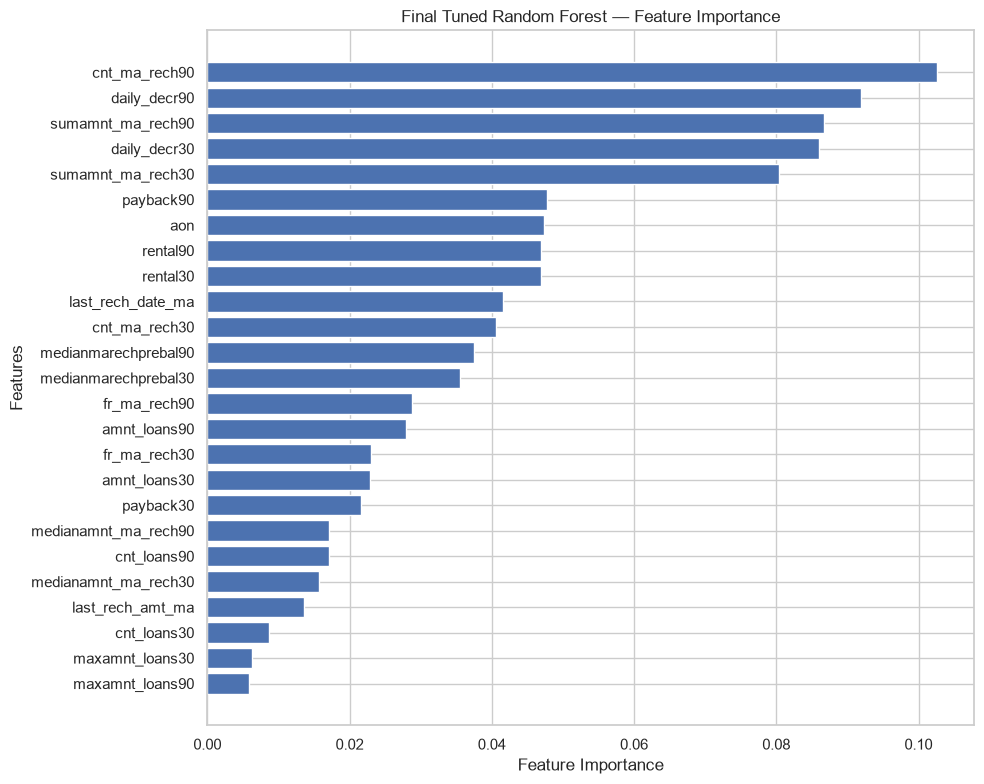

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FINAL MODEL FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL TUNED RANDOM FOREST — FEATURE IMPORTANCE")
print("=" * 70)

print(feature_importance.to_string(index=False))


# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Final Tuned Random Forest — Feature Importance")

plt.tight_layout()
plt.show()

## 39. Final Tuned Random Forest — ROC-AUC and Precision-Recall Evaluation

The final tuned Random Forest is evaluated using probability-based metrics.

ROC-AUC measures the model's ability to distinguish between the repayment
classes across different classification thresholds.

Average Precision (AP) summarizes the Precision-Recall relationship and is
particularly useful for evaluating classification performance when the
target classes are imbalanced.

FINAL TUNED RANDOM FOREST — ROC-AUC
ROC-AUC Score : 0.9026


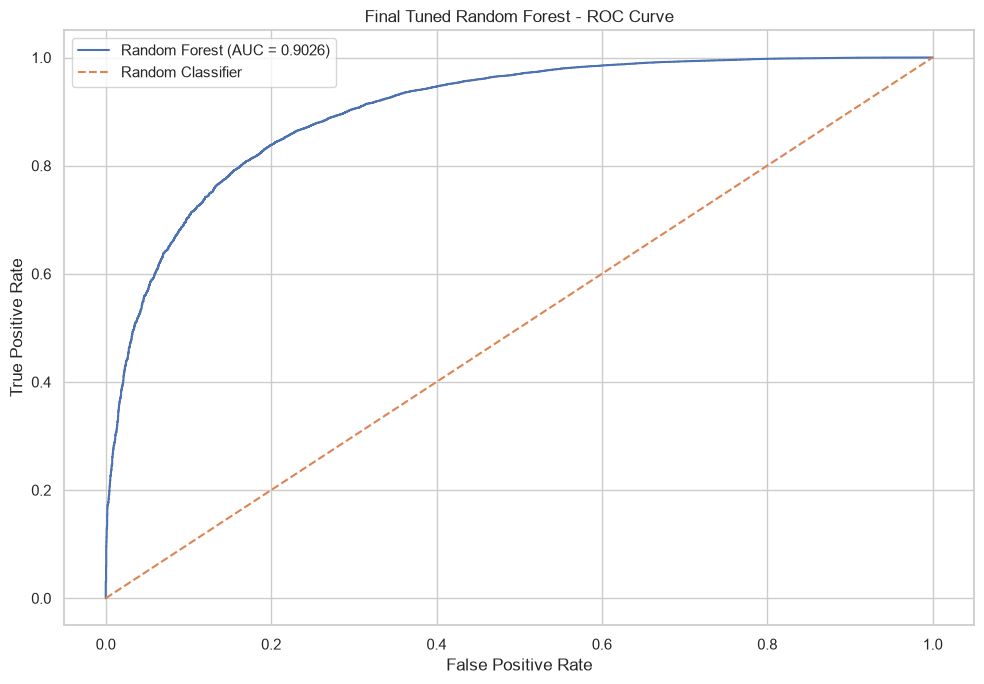


FINAL TUNED RANDOM FOREST — PRECISION-RECALL
Average Precision : 0.9828


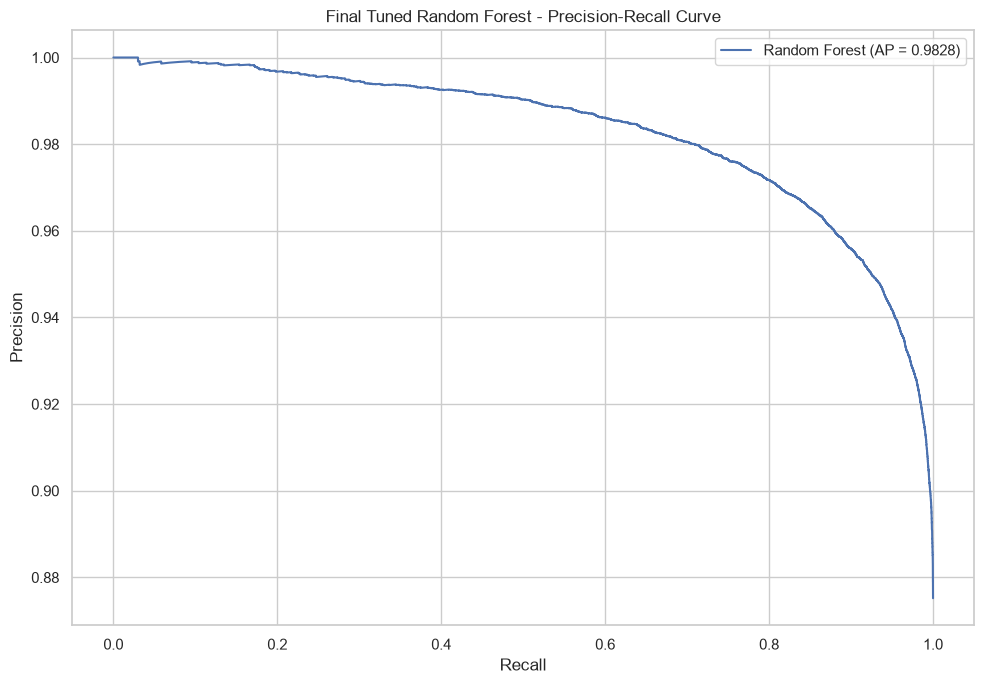

In [90]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# ============================================================
# PREDICT PROBABILITIES
# ============================================================

final_probabilities = final_model.predict_proba(
    X_test_scaled
)[:, 1]


# ============================================================
# ROC-AUC
# ============================================================

roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

fpr, tpr, _ = roc_curve(
    y_test,
    final_probabilities
)

print("=" * 70)
print("FINAL TUNED RANDOM FOREST — ROC-AUC")
print("=" * 70)

print(f"ROC-AUC Score : {roc_auc:.4f}")


# ============================================================
# ROC CURVE
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Tuned Random Forest - ROC Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# PRECISION-RECALL
# ============================================================

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    final_probabilities
)

average_precision = average_precision_score(
    y_test,
    final_probabilities
)

print("\n" + "=" * 70)
print("FINAL TUNED RANDOM FOREST — PRECISION-RECALL")
print("=" * 70)

print(f"Average Precision : {average_precision:.4f}")


# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Random Forest (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Tuned Random Forest - Precision-Recall Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 39B. Final Tuned Random Forest — Precision-Recall Evaluation

The Precision-Recall curve evaluates the trade-off between precision and
recall across different classification thresholds.

Average Precision (AP) is reported as a summary measure of the
Precision-Recall performance.

FINAL TUNED RANDOM FOREST — PRECISION-RECALL
Average Precision : 0.9828


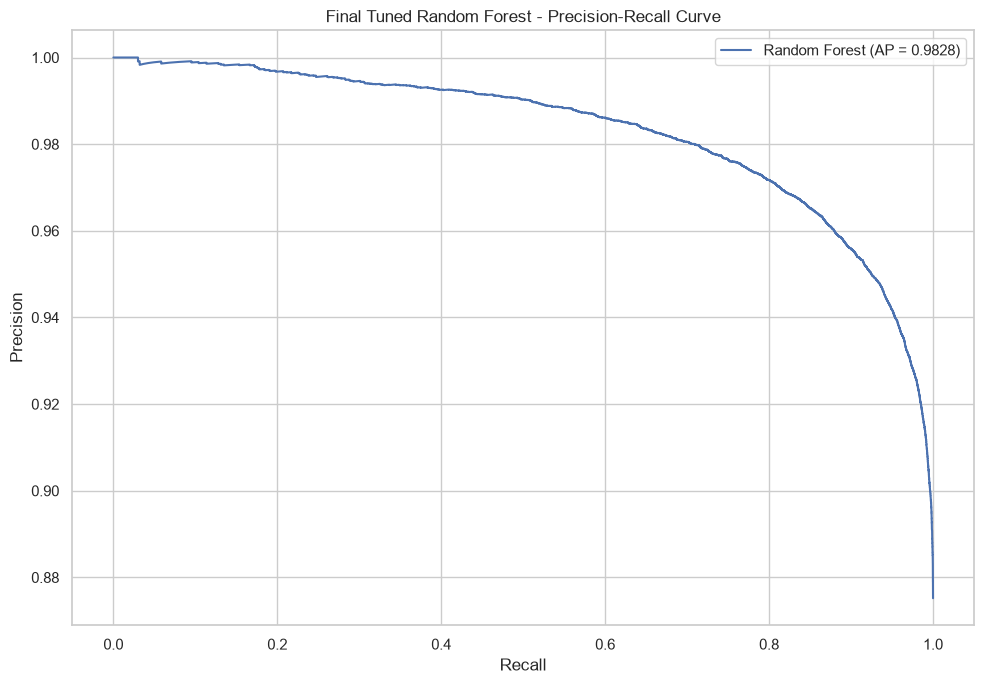

In [91]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    final_probabilities
)

average_precision = average_precision_score(
    y_test,
    final_probabilities
)

print("=" * 70)
print("FINAL TUNED RANDOM FOREST — PRECISION-RECALL")
print("=" * 70)

print(f"Average Precision : {average_precision:.4f}")


# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Random Forest (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Final Tuned Random Forest - Precision-Recall Curve"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 40. Save Final Random Forest Model

The final tuned Random Forest and all preprocessing artifacts are saved
for future prediction and deployment.

The saved artifacts ensure that future input data uses the same selected
features, scaling procedure, model configuration, and classification
threshold used during model development.

In [92]:
import os
import json
import joblib

# ============================================================
# CREATE MODEL DIRECTORY
# ============================================================

os.makedirs("../models", exist_ok=True)


# ============================================================
# SAVE FINAL MODEL
# ============================================================

joblib.dump(
    final_model,
    "../models/final_random_forest.pkl"
)


# ============================================================
# SAVE SCALER
# ============================================================

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)


# ============================================================
# SAVE SELECTED FEATURES
# ============================================================

with open(
    "../models/selected_features.json",
    "w"
) as f:

    json.dump(
        selected_features,
        f,
        indent=4
    )


# ============================================================
# SAVE CLASSIFICATION THRESHOLD
# ============================================================

with open(
    "../models/classification_threshold.json",
    "w"
) as f:

    json.dump(
        {
            "threshold": final_threshold
        },
        f,
        indent=4
    )


# ============================================================
# SAVE MODEL METADATA
# ============================================================

metadata = {
    "model": "RandomForestClassifier",
    "n_estimators": 300,
    "max_depth": 25,
    "min_samples_split": 10,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "n_features": len(selected_features),
    "threshold": float(final_threshold),

    "accuracy": float(final_accuracy),
    "precision": float(final_precision),
    "recall": float(final_recall),
    "f1_score": float(final_f1),
    "macro_f1": float(final_macro_f1),
    "balanced_accuracy": float(final_balanced_accuracy),
    "roc_auc": float(roc_auc),
    "average_precision": float(average_precision)
}

with open(
    "../models/model_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# CONFIRMATION
# ============================================================

print("=" * 70)
print("FINAL MODEL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 70)

print("1. final_random_forest.pkl")
print("2. scaler.pkl")
print("3. selected_features.json")
print("4. classification_threshold.json")
print("5. model_metadata.json")

FINAL MODEL ARTIFACTS SAVED SUCCESSFULLY
1. final_random_forest.pkl
2. scaler.pkl
3. selected_features.json
4. classification_threshold.json
5. model_metadata.json


## 41. Final Model Artifact Verification

The saved Random Forest model, scaler, selected feature list, and
classification threshold are loaded back from disk.

The loaded model is then used to generate predictions on the test data
to verify that the saved artifacts can reproduce the final model output.

In [93]:
import joblib
import json
import numpy as np

# ============================================================
# LOAD SAVED ARTIFACTS
# ============================================================

loaded_model = joblib.load(
    "../models/final_random_forest.pkl"
)

loaded_scaler = joblib.load(
    "../models/scaler.pkl"
)

with open(
    "../models/selected_features.json",
    "r"
) as f:
    loaded_features = json.load(f)

with open(
    "../models/classification_threshold.json",
    "r"
) as f:
    loaded_threshold = json.load(f)["threshold"]


# ============================================================
# VERIFY FEATURES
# ============================================================

print("=" * 70)
print("FINAL MODEL ARTIFACT VERIFICATION")
print("=" * 70)

print(f"Loaded model       : {type(loaded_model).__name__}")
print(f"Selected features  : {len(loaded_features)}")
print(f"Threshold          : {loaded_threshold}")


# ============================================================
# VERIFY SCALER
# ============================================================

X_test_loaded_scaled = loaded_scaler.transform(
    X_test[selected_features]
)


# ============================================================
# GENERATE PREDICTIONS
# ============================================================

loaded_probabilities = loaded_model.predict_proba(
    X_test_loaded_scaled
)[:, 1]

loaded_predictions = (
    loaded_probabilities >= loaded_threshold
).astype(int)


# ============================================================
# COMPARE WITH ORIGINAL MODEL
# ============================================================

prediction_match = np.array_equal(
    final_predictions,
    loaded_predictions
)

probability_match = np.allclose(
    final_probabilities,
    loaded_probabilities
)


print("\n" + "=" * 70)
print("PREDICTION VERIFICATION")
print("=" * 70)

print(f"Prediction match   : {prediction_match}")
print(f"Probability match  : {probability_match}")

print("\nVerification completed.")

FINAL MODEL ARTIFACT VERIFICATION
Loaded model       : RandomForestClassifier
Selected features  : 25
Threshold          : 0.5

PREDICTION VERIFICATION
Prediction match   : True
Probability match  : True

Verification completed.
